# TSFresh-Features aus rohem und DyCVDA-gefiltertem TEP-Signal

Drittes Schwester-Notebook zu `TSFresh_PCA_DyCA.ipynb` und
`TSFresh_DPCA_CVA_ICA.ipynb`: identische dreiphasige Pipeline (Extraktion +
Selektion auf Train, billige Test-Extraktion, LazyClassifier), aber mit
**DyCVDA** als Projektion (*Dynamical and Canonical Variate Dissimilarity
Analysis*, Wu et al., IEEE Trans. Autom. Sci. Eng. 23, 2026, S. 9560–9570).
`raw` läuft als gemeinsamer Anker mit — dadurch sind die Ergebnisse aller drei
Notebooks direkt aneinander ausrichtbar.

## Was DyCVDA ist

DyCVDA verkettet zwei Stufen, die es in der Notebook-Familie beide schon
einzeln gibt:

1. **DyCA** (identisch zur `dyca_*`-Projektion des ersten
   Schwester-Notebooks): zerlegt die 52 Prozessvariablen in *n*
   deterministische Amplituden y(t), deren zeitliche Entwicklung ein
   gekoppeltes lineares ODE-System optimal erfüllt (Paper Gl. 5–11).
2. **CVA-Dissimilarität** (verwandt mit der `cva_*`-Projektion des zweiten
   Schwester-Notebooks, aber auf den DyCA-Amplituden statt auf den Rohdaten,
   mit Horizont *s* statt p = f = 1 und mit Zukunftsterm): aus
   Vergangenheits- und Zukunftsstapeln y_p(t), y_f(t) wird per kanonischer
   Korrelationsanalyse die Projektion (J, L, Λ) bestimmt und daraus die
   **Dissimilaritätskanäle** d(t) = J·y_p(t) − Λ_r·L·y_f(t)
   (Paper Gl. 12–15).

Im Paper ist d(t) der Rohstoff eines skalaren Monitoring-Index D(t)
(Mahalanobis-Distanz mit KDE-Kontrollgrenze, Gl. 16–19) zur
Fehler-**Detektion**. Hier interessiert Fehler-**Klassifikation**: statt des
skalaren Index geht die r-kanalige d(t)-Zeitreihe in TSFresh — genau wie bei
allen anderen Projektionen der Familie. Details und die bewusste Abweichung
vom Paper (Fit pro Run statt Offline-Training auf Normalbetrieb) stehen im
Projektions-Abschnitt weiter unten.

## Die 7 Konfigurationen

| Konfiguration | Kanäle | DyCA (m, n) | Horizont s | Bemerkung |
|---|---|---|---|---|
| `raw` | 52 | — | — | keine Projektion; bitidentisch zu den Schwester-Notebooks |
| `dycvda_m3n6_s2_r6` | 6 | (3, 6) | 2 | kleine DyCA-Stufe |
| `dycvda_m4n8_s2_r8` | 8 | (4, 8) | 2 | mittlere DyCA-Stufe |
| `dycvda_m6n12_s2_r12` | 12 | (6, 12) | 2 | DyCA-Stufe = `dyca_m6_n12` des Schwester-Notebooks |
| `dycvda_m6n12_s2_r15` | 15 | (6, 12) | 2 | Paper-Setting für TEP: 12 det. Komponenten, s = 2, r = 15 |
| `dycvda_m6n12_s4_r12` | 12 | (6, 12) | 4 | längerer Horizont |
| `dycvda_m6n12_s8_r12` | 12 | (6, 12) | 8 | noch längerer Horizont |

Zusammen 52 + 65 = **117 Kanäle pro Run**. Alle vier Parameter (m, n, s, r)
stecken im Konfigurationsnamen und damit im Cache-Präfix — ein
Parameterwechsel erzeugt neue Konfigurationen, statt stumm fremde Chunks zu
laden (anders als `DPCA_LAGS`/`CVA_PAST` im Schwester-Notebook; Ausnahmen
sind nur `CVA_RIDGE_REL` und `FIX_SIGNS`, die beide nicht im Namen stecken —
siehe Konfigurationszelle).

**Hinweis zur Verschachtelung.** Die CVA-Stufe ist in r verschachtelt wie PCA
in n: `dycvda_m6n12_s2_r15` enthält die 12 Kanäle von `…_r12` als exakte
Teilmenge, die drei zusätzlichen Kanäle sind die schwächsten kanonischen
Korrelationen. Ob die Top-100-Auswahl jenseits von Kanal 12 überhaupt
zugreift, zeigt der Vergleich der beiden Auswahl-JSONs — dasselbe Phänomen,
das bei `pca_6`/`pca_8` zu byteidentischen Ergebnissen geführt hat. Die s-
und (m, n)-Varianten sind dagegen **echt** verschiedene Projektionen.

## Kanallängen — kleine, dokumentierte Abweichung

Die Stapelbildung verkürzt die d(t)-Reihe auf 480 − 2s + 1 Samples: **477**
(s = 2), **473** (s = 4), **465** (s = 8); `raw` behält **480**. Das ist
unkritisch, weil die Regel „keine Längenartefakte" nur *innerhalb* einer
Konfiguration greifen muss: dort sind alle Runs und beide Splits exakt gleich
lang. Zwischen Konfigurationen werden Features nie verglichen — jede bekommt
ihre eigene Selektion und ihren eigenen Klassifizierer. `raw` bleibt bewusst
bei 480, damit die raw-Ergebnisse mit den Schwester-Notebooks bitidentisch
sind und der Cache geteilt werden kann (siehe unten).

## Gemeinsamer Cache mit den Schwester-Notebooks

`CACHE_DIR` ist absichtlich **derselbe** (`tsfresh_cache` bzw.
`tsfresh_cache_smoke`): die `raw`-Konfiguration ist in allen drei Notebooks
bitidentisch (gleiche Vorverarbeitung, gleiche Länge, gleiches Chunking) —
vorhandene raw-Chunks und die raw-Top-`TOP_K`-Auswahl werden dadurch
**wiederverwendet**, was bei bereits gelaufenen Schwester-Notebooks rund
5,5 h spart. Zwei Konsequenzen:

- **`CHUNK_RUNS` muss auf 250 bleiben** (Wert der Schwester-Notebooks) —
  sonst würden deren Cache-Dateien mit falscher Chunk-Aufteilung
  interpretiert und Runs stumm verloren gehen.
- Die Ergebnis-CSV heißt hier `tsfresh_summary_dycvda.csv`, damit die
  Summary-CSVs der Schwester-Notebooks nicht überschrieben werden.

Das Präfix `dycvda_*` kollidiert mit nichts Bestehendem.

## Vorgehen (dreistufig)

**Phase A — Extraktion + Selektion auf TRAIN.** Je Konfiguration werden alle
TSFresh-Features auf allen Trainingsruns berechnet (`EfficientFCParameters`,
~780 Features je Kanal), daraus per Relevanztabelle die besten `TOP_K`
ausgewählt. Danach wird die volle Matrix sofort verworfen.

**Phase B — Testset.** `from_columns()` übersetzt die ausgewählten
Featurenamen zurück in `kind_to_fc_parameters`; auf dem Testset werden nur
diese Features berechnet. Die Selektion sieht das Testset nie.

**Phase C — LazyClassifier** je Konfiguration, dann Vergleich über alle 7.

## Laufzeit und Speicher — bitte vor dem Start lesen

Maßstab aus dem vollständigen Lauf des ersten Schwester-Notebooks (8 Kerne,
`EfficientFCParameters`, alle 500 Runs je Fault): ~6,5 min TSFresh-Zeit pro
Kanal in Phase A. Hier: `raw` aus dem Cache ≈ 0 h (sonst ~5,5 h), die 6
DyCVDA-Konfigurationen ≈ 65 Kanäle → Phase A grob **7 h**, dazu die
DyCA+CVA-Fits (6 × 10 500 Runs) mit grob **1 h** in Phase A und nochmals
~1 h in Phase B. Phase B insgesamt ~2–3 h, Phase C mit 5-facher CV ~1 h.
Zusammen Größenordnung **10–13 h** bei vorhandenem raw-Cache.

Speicher ist unkritischer als im ersten Schwester-Notebook: die größte neue
Konfiguration hat 15 Kanäle (~11 700 Features/Run); nur `raw` (40 404
Features/Run) bleibt groß — und kommt in der Regel aus dem Cache. Die
Mechanik (float32-Matrizen, Konfigurationen strikt nacheinander,
Relevanztests in Spaltenblöcken, Chunk-Cache) ist identisch.

**Der Cache macht den Lauf unterbrechbar.** Jeder Chunk landet als Pickle in
`CACHE_DIR`; ein Neustart überspringt alles bereits Berechnete.

> **`SMOKE_TEST` steht in der Konfigurationszelle.** Mit `True` läuft die
> komplette Pipeline in wenigen Minuten auf wenigen Runs durch. Für den
> echten Lauf auf `False` (am besten über Nacht).

In [1]:
# ============================================================
# Imports
# ============================================================
import os
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.feature_selection import f_classif
from sklearn.metrics import balanced_accuracy_score, f1_score

from dyca import dyca

from tsfresh import extract_features
from tsfresh.feature_extraction.settings import (
    MinimalFCParameters, EfficientFCParameters, ComprehensiveFCParameters,
    from_columns)
from tsfresh.feature_selection.relevance import calculate_relevance_table
from tsfresh.utilities.dataframe_functions import impute

from lazypredict.Supervised import LazyClassifier

try:
    from tqdm.auto import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False

import tsfresh
print("tsfresh", tsfresh.__version__, "| pandas", pd.__version__,
      "| numpy", np.__version__, "| Kerne:", os.cpu_count())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================

# SMOKE_TEST=True -> winziger Durchlauf (Minuten) zum Pruefen der Pipeline.
# Fuer den echten Lauf auf False setzen. Die Caches beider Modi liegen in
# getrennten Verzeichnissen, ueberschreiben sich also nicht.
SMOKE_TEST = False

DATA_DIR = "."                      # hier liegen die TEP-CSVs

# ===== DyCVDA-Parameter (Wu et al. 2026, IEEE TASE 23, S. 9560-9570) =====
# Jede Konfiguration ist ein Tupel (m, n, s, r):
#   m, n : DyCA-Stufe wie im Schwester-Notebook TSFresh_PCA_DyCA
#          (m lineare ODE-Komponenten, n deterministische Amplituden;
#          n = 2m ist der Grenzfall der Paketbedingung m >= n - m)
#   s    : Vergangenheits-/Zukunftshorizont der CVA-Stufe (Paper: s = 2)
#   r    : behaltene Dissimilaritaetskanaele d_1..d_r (r <= n*s)
# Alle vier Parameter stecken im Konfigurationsnamen (dycvda_m6n12_s2_r12)
# und damit im Cache-Praefix - anders als bei DPCA_LAGS/CVA_PAST im
# Schwester-Notebook kann ein Parameterwechsel hier KEINE fremden Chunks
# stumm weiterverwenden. Ausnahmen: CVA_RIDGE_REL und FIX_SIGNS stecken
# nicht im Namen (siehe unten).
DYCVDA_CONFIGS = [
    (3, 6,  2, 6),      # kleine DyCA-Stufe
    (4, 8,  2, 8),      # mittlere DyCA-Stufe
    (6, 12, 2, 12),     # DyCA-Stufe = dyca_m6_n12 des Schwester-Notebooks
    (6, 12, 2, 15),     # Paper-Setting fuer TEP: 12 det. Komp., s=2, r=15
    (6, 12, 4, 12),     # laengerer Horizont
    (6, 12, 8, 12),     # noch laengerer Horizont
]

# Relative Ridge-Regularisierung der CVA-Stufe (wie CVA_RIDGE_REL im
# Schwester-Notebook). Steckt NICHT im Cache-Namen - bei Aenderung vorher
# die dycvda_*-Chunks aus CACHE_DIR loeschen.
CVA_RIDGE_REL = 1e-6

for _m, _n, _s, _r in DYCVDA_CONFIGS:
    # Paketbedingung von dyca und Rangbedingung der CVA-Stufe.
    assert _m >= _n - _m, f"dyca verlangt m >= n - m, verletzt von {(_m, _n)}"
    assert _r <= _n * _s, f"r <= n*s verletzt von {(_m, _n, _s, _r)}"

TOP_K       = 100          # so viele Features je Konfiguration behalten
FC_MODE     = "efficient"  # minimal | efficient | comprehensive
# ACHTUNG: CHUNK_RUNS MUSS beim Wert der Schwester-Notebooks (250)
# bleiben, solange CACHE_DIR geteilt wird - die Chunk-Dateien sind ueber
# den Index an die Aufteilung gebunden; ein anderer Wert wuerde fremde
# Chunks falsch interpretieren und Runs stumm verlieren.
CHUNK_RUNS  = 250          # Runs je Extraktions-Chunk (Cache-Granularitaet)
N_JOBS      = os.cpu_count() or 4   # bei Problemen mit Multiprocessing: 0
RUNS_PER_FAULT = None      # None = alle 500 Runs je Fault
BLOCK_COLS  = 4000         # Spalten je Block im Relevanztest (RAM-Bremse)

# Pre-Fault-Cutoff wie in den bestehenden Notebooks:
# Train  = Fehler nach 1 h  -> erstes Post-Fault-Sample 21  (500 Samples/Run)
# Test   = Fehler nach 8 h  -> erstes Post-Fault-Sample 161 (960 Samples/Run)
PRE_FAULT_CUTOFF = {"train": 21, "test": 161}

# WICHTIG (wie in den Schwester-Notebooks): der Cutoff wird auch auf Fault 0
# angewandt, damit ALLE Runs exakt gleich lang sind - laengenabhaengige
# TSFresh-Features wuerden Fault 0 sonst rein artifiziell abtrennen.
UNIFORM_LENGTH = True

# Und zwar ueber BEIDE Splits hinweg: alle Runs werden auf dieselbe
# Laenge gekuerzt - 480 Post-Fault-Samples = 24 h nach Fehlereintritt,
# in Train wie Test dasselbe Zeitfenster. None schaltet die Kuerzung ab.
RUN_LENGTH = 480

# Vorzeichenkonvention fuer die Projektionen (siehe Markdown weiter unten).
# Steckt wie CVA_RIDGE_REL nicht im Cache-Namen - bei Aenderung vorher die
# dycvda_*-Chunks aus CACHE_DIR loeschen.
FIX_SIGNS = True

# Vorverarbeitung vor der Projektion. "global_mean" ist die Zeile aus den
# Eigenwert-Notebooks (X - X.mean(), skalarer Gesamtmittelwert); "scaler"
# ist die spaltenweise Standardisierung auf Normalbetriebs-Einheiten.
# Die DyCA-Stufe ist bei "global_mean" DC-dominiert (siehe Markdown im
# Schwester-Notebook TSFresh_PCA_DyCA); die CVA-Stufe zentriert ihre
# Stapel aber explizit, der Gleichanteil faellt dort wieder heraus.
# Was bleibt, ist sein Einfluss auf die DyCA-Unterraumwahl selbst -
# Details im Projektions-Markdown.
SCALING_MODE = "global_mean"        # "global_mean" | "scaler"

# Vergleich auf identischer Run-Menge ueber alle Konfigurationen. Die
# DyCA-Stufe kann an einzelnen Runs numerisch scheitern ("Negative
# eigenvalues"); ohne das waeren die 7 Setups auf unterschiedlichen
# Testmengen bewertet.
RESTRICT_TO_COMMON_RUNS = True

# 5-fache CV auf den TRAININGSdaten (wie CV_FOLDS im Eigenwert-Notebook):
# liefert die Spalten "... CV Mean/Std" und damit eine Modellauswahl OHNE
# Blick aufs Testset. lazypredict rechnet die Folds mit n_jobs=-1 parallel,
# Phase C dauert dadurch grob das 2- bis 4-Fache; Phase A/B sind nicht
# betroffen. 0 schaltet die CV wieder ab.
LC_CV_FOLDS = 5            # 0 = kein CV (nur Train/Test). >0 = LazyClassifier(cv=...)

if SMOKE_TEST:
    RUNS_PER_FAULT = 4
    FC_MODE        = "minimal"
    TOP_K          = 20
    CHUNK_RUNS     = 50

# GETEILTER Cache mit den Schwester-Notebooks (Begruendung im Markdown):
# die raw-Konfiguration ist bitidentisch, ihre Chunks und die
# Top-K-Auswahl werden wiederverwendet. Der Skalierungsmodus steckt im
# Namen, damit ein Umschalten nicht stumm alte Features laedt.
CACHE_DIR = ("tsfresh_cache_smoke" if SMOKE_TEST else "tsfresh_cache")
if SCALING_MODE != "global_mean":
    CACHE_DIR += f"_{SCALING_MODE}"
os.makedirs(CACHE_DIR, exist_ok=True)

# Eigene Ergebnis-CSV, damit die Summary-CSVs der Schwester-Notebooks
# nicht ueberschrieben werden.
SUMMARY_CSV = "tsfresh_summary_dycvda.csv"

FC_PARAMETERS = {"minimal": MinimalFCParameters,
                 "efficient": EfficientFCParameters,
                 "comprehensive": ComprehensiveFCParameters}[FC_MODE]()

XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42)]
XMV_COLS   = [f"xmv_{i}"   for i in range(1, 12)]
PROC_COLS  = XMEAS_COLS + XMV_COLS
META_COLS  = ["faultNumber", "simulationRun", "sample"]

print(f"SMOKE_TEST={SMOKE_TEST} | FC_MODE={FC_MODE} "
      f"({len(FC_PARAMETERS)} Calculator) | TOP_K={TOP_K}")
print(f"Runs je Fault: {RUNS_PER_FAULT or 'alle'} | Cache: {CACHE_DIR}/ "
      f"(geteilt mit den Schwester-Notebooks)")
if not SMOKE_TEST:
    print("\n!!! VOLLER LAUF - Groessenordnung 10-13 h bei vorhandenem "
          "raw-Cache (sonst +5,5 h). Der Chunk-Cache macht Abbrechen und "
          "Fortsetzen gefahrlos. !!!")

SMOKE_TEST=False | FC_MODE=efficient (73 Calculator) | TOP_K=100
Runs je Fault: alle | Cache: tsfresh_cache/ (geteilt mit den Schwester-Notebooks)

!!! VOLLER LAUF - Groessenordnung 10-13 h bei vorhandenem raw-Cache (sonst +5,5 h). Der Chunk-Cache macht Abbrechen und Fortsetzen gefahrlos. !!!


## Rohdaten laden

Identisch zu den Schwester-Notebooks: die Runs werden **einmal** in ein Dictionary
`{(faultNumber, simulationRun): Array}` gelesen und danach für alle 7
Konfigurationen wiederverwendet — die TEP-CSVs (besonders
`TEP_Faulty_Testing.csv` mit 3,4 GB) sollen nur ein Mal durch den Parser.

Speicher: mit `float32` und nur den benötigten Spalten sind das je ~1,05 GB
für Train und Test (beide Splits werden auf `RUN_LENGTH` gekürzt). Train und
Test werden **nie gleichzeitig** gehalten — Phase A braucht nur Train,
Phase B nur Test.

Sortiert wird pro Run (nicht global), weil ein globales `sort_values` über
10 Mio. Zeilen eine komplette Kopie anlegen würde. Die DyCA-Stufe
(Ableitungsschätzung) und die CVA-Stufe (Vergangenheits-/Zukunftsstapel)
brauchen die zeitliche Ordnung zwingend.

### `UNIFORM_LENGTH` und `RUN_LENGTH`

Beide Schalter übernehmen unverändert die Begründung aus
`TSFresh_PCA_DyCA.ipynb`: längenabhängige TSFresh-Features (`length`,
`abs_energy`, `sum_values`, `count_above_mean`, …) würden sonst Fault 0
artifiziell abtrennen (innerhalb eines Splits) bzw. Train- und Test-Features
systematisch verschieden skalieren (zwischen den Splits: 480 vs. 800
Post-Fault-Samples). `RUN_LENGTH = 480` kürzt deshalb **jeden** Run auf die
ersten 480 Post-Fault-Samples = 24 h nach Fehlereintritt — in beiden Splits
dasselbe physikalische Fenster.

Dass die Projektion daraus config-spezifisch 465–480 Samples macht, ist
davon unberührt — innerhalb jeder Konfiguration bleiben alle Runs und beide
Splits exakt gleich lang (siehe Kanallängen-Abschnitt oben).

In [3]:
# ============================================================
# Rohdaten laden: dict[(fault, run)] -> float32-Array (T, 52)
# ============================================================
SPLIT_FILES = {
    "train": ("TEP_FaultFree_Training.csv", "TEP_Faulty_Training.csv"),
    "test":  ("TEP_FaultFree_Testing.csv",  "TEP_Faulty_Testing.csv"),
}


def run_id(fault, run):
    """Eindeutige Integer-ID je (fault, run) fuer tsfresh (column_id).
    Runs laufen 1..500, deshalb ist fault*1000+run kollisionsfrei und
    per Division wieder zerlegbar."""
    return int(fault) * 1000 + int(run)


def load_runs(split):
    """Liest einen Split und liefert dict[(fault, run)] -> (T, 52) float32."""
    cutoff = PRE_FAULT_CUTOFF[split]
    dtypes = {c: "float32" for c in PROC_COLS}
    dtypes.update({c: "int32" for c in META_COLS})

    runs = {}
    for fname in SPLIT_FILES[split]:
        path = os.path.join(DATA_DIR, fname)
        if not os.path.exists(path):
            raise FileNotFoundError(f"{path} nicht gefunden.")
        print(f"  lese {fname} ...", flush=True)
        df = pd.read_csv(path, usecols=META_COLS + PROC_COLS, dtype=dtypes)

        if RUNS_PER_FAULT is not None:
            df = df[df["simulationRun"] <= RUNS_PER_FAULT]

        for (fault, run), g in df.groupby(["faultNumber", "simulationRun"],
                                          sort=True):
            g = g.sort_values("sample")            # klein: <= 960 Zeilen
            # Pre-Fault verwerfen. Bei UNIFORM_LENGTH auch fuer Fault 0,
            # damit alle Runs gleich lang sind (siehe Markdown).
            if fault != 0 or UNIFORM_LENGTH:
                g = g[g["sample"] >= cutoff]
            arr = g[PROC_COLS].to_numpy(dtype=np.float32)
            # Auf gemeinsame Laenge kuerzen, damit Train (480) und Test (800)
            # dasselbe Zeitfenster nach Fehlereintritt abdecken.
            if RUN_LENGTH is not None:
                if arr.shape[0] < RUN_LENGTH:
                    raise ValueError(
                        f"Run (fault={fault}, run={run}) hat nur {arr.shape[0]} "
                        f"Samples, RUN_LENGTH={RUN_LENGTH} verlangt mehr.")
                arr = arr[:RUN_LENGTH]
            runs[(int(fault), int(run))] = arr

        del df
        gc.collect()

    lens = sorted({v.shape[0] for v in runs.values()})
    print(f"  {split}: {len(runs)} Runs, Laenge(n) {lens}, "
          f"{sum(v.nbytes for v in runs.values()) / 1e9:.2f} GB")
    if len(lens) > 1:
        print("  ACHTUNG: unterschiedliche Runlaengen -> laengenabhaengige "
              "TSFresh-Features (length, abs_energy, ...) trennen Klassen "
              "artifiziell. UNIFORM_LENGTH pruefen!")
    return runs

## Projektionen: roh und DyCVDA

Beide Varianten bekommen **dieselbe Vorverarbeitung**, gesteuert über
`SCALING_MODE` — zwischen den Konfigurationen unterscheidet sich wirklich nur
die Projektion. DyCVDA wird — wie alle Projektionen dieser Notebook-Familie —
**pro Run gefittet** (Begründung unten).

### `SCALING_MODE` — die DC-Problematik wird in der CVA-Stufe entschärft

Die DC-Problematik des ersten Schwester-Notebooks gilt für die DyCA-Stufe
hier unverändert: mit `"global_mean"` bleibt in jeder Spalte ein großer
Gleichanteil stehen, die DyCA-Amplituden sind DC-dominiert
(std/|mean| ~ 1e-5…1e-3). Zwei Dinge entschärfen das für DyCVDA:

- Die **CVA-Stufe zentriert** ihre Vergangenheits-/Zukunftsstapel explizit —
  der Gleichanteil fällt vor der Korrelationsrechnung wieder heraus. In
  float64 kostet das keine relevante Genauigkeit (nach Abzug von 3–5
  Größenordnungen DC bleiben ~11 signifikante Stellen).
- Die Dissimilaritätskanäle haben per Konstruktion **Kovarianz I − Λ_r²**
  (auf den Fit-Daten), sind also von der Skala der Amplituden unabhängig.

Was bleibt, ist der Einfluss des Gleichanteils auf die **Unterraumwahl der
DyCA-Stufe selbst** — welcher Unterraum als „deterministisch" erkannt wird,
hängt an der unzentrierten Korrelationsmatrix. **Aktuell ist `"global_mean"`
eingestellt** — konsistent mit den Schwester-Notebooks; der Vergleich mit dem
Scaler-Lauf (`tsfresh_cache_scaler`) zeigt, wie groß dieser Effekt ist.

### Fit pro Run — bewusste Abweichung vom Paper

Im Paper wird DyCVDA **offline** auf Normalbetriebsdaten trainiert (Θ‡, J,
L, Λ fest) und online werden Abweichungen vom Normalbetrieb detektiert. Hier
wird stattdessen pro Run gefittet, aus denselben Gründen wie bei allen
anderen Projektionen der Familie: Methode und Fit-Modus nicht vermischen
(pca/dyca/dpca/cva/ica sind alle pro Run gefittet), und DyCA sucht ohnehin
den Unterraum *dieses* Laufs.

Die Bedeutung von d(t) verschiebt sich dadurch: statt „Abweichung vom
Normalbetrieb" misst d(t), wie schlecht sich die DyCA-Dynamik **dieses Runs**
durch ihre eigene Vergangenheits-/Zukunfts-Korrelationsstruktur erklären
lässt — die Kanäle sind die am stärksten korrelierten Richtungen, d(t) deren
Residuum. TSFresh charakterisiert anschließend die *Form* dieser Residuen
(Autokorrelation, Spektrum, Ausreißerstatistik, …), und die Klassifikation
prüft, ob diese Form faultspezifisch ist. Die papiertreue Offline-Variante
steht als Erweiterung in der letzten Zelle.

### Definition (Paper Gl. 12–15)

Je Run, auf den n DyCA-Amplituden y(t):

- Stapel: y_p(t) = [y(t−1); …; y(t−s)], y_f(t) = [y(t); …; y(t+s−1)],
  beide zentriert (das Paper normalisiert die Daten vorab).
- CVA: H = Σ_ff^(−1/2) Σ_fp Σ_pp^(−1/2) = U Λ Vᵀ, dann
  J = V_rᵀ Σ_pp^(−1/2), L = U_rᵀ Σ_ff^(−1/2) (Ridge wie im CVA-Notebook).
- Kanäle: d(t) = J·y_p(t) − Λ_r·L·y_f(t), geordnet nach kanonischer
  Korrelation absteigend (`cvd1` = stärkste) — deterministisch, keine
  Ordnungswillkür wie bei ICA.

**Selbsttest der Implementierung:** auf den Fit-Daten gilt exakt
cov(d) = I − Λ_r² (ohne Ridge auf Maschinengenauigkeit verifiziert, mit
Ridge bis ~1e-6). Serienlänge 480 − 2s + 1 (siehe Kanallängen-Abschnitt).

**Vorzeichenkonvention.** Die d-Kanäle erben die Vorzeichen-Willkür der SVD
(u_i, v_i) → (−u_i, −v_i) — TSFresh-Features wie `mean`, `skewness` oder die
Steigung von `linear_trend` kippen mit. `FIX_SIGNS=True` dreht deshalb jeden
Kanal so, dass sein betragsmäßig größter Wert positiv ist — dieselbe
Konvention wie in den Schwester-Notebooks.

**Skip-Verhalten.** Die DyCA-Stufe kann an einzelnen Runs numerisch scheitern
(„Negative eigenvalues", wie im Schwester-Notebook); solche Runs werden für
die betroffene Konfiguration übersprungen, `RESTRICT_TO_COMMON_RUNS` gleicht
die Run-Mengen in Phase C wieder an.

Bleibt die Einschränkung, dass pro Run gefittete Achsen in verschiedenen Runs
verschiedene physikalische Richtungen sind. Formstatistiken (Autokorrelation,
Spektrum, Entropie) bleiben vergleichbar; lageabhängige Features sind mit
Vorsicht zu lesen. Das ist derselbe Preis wie in den Schwester-Notebooks.

In [4]:
# ============================================================
# Projektionsfunktionen + Liste der 7 Konfigurationen
# ============================================================

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
SCALER = None
if SCALING_MODE == "scaler":
    from sklearn.preprocessing import StandardScaler
    print("Fitte StandardScaler auf TEP_FaultFree_Training (Normalbetrieb) ...")
    _ff = pd.read_csv(os.path.join(DATA_DIR, "TEP_FaultFree_Training.csv"),
                      usecols=PROC_COLS)
    SCALER = StandardScaler().fit(_ff[PROC_COLS].values)
    del _ff
    _ = gc.collect()
    print("  fertig.")


def _fix_signs(Y):
    """Dreht jeden Kanal so, dass sein betragsmaessig groesster Wert positiv
    ist. Behebt die Vorzeichen-Willkuer der pro Run gefitteten Achsen."""
    idx = np.argmax(np.abs(Y), axis=0)
    signs = np.sign(Y[idx, np.arange(Y.shape[1])])
    signs[signs == 0] = 1.0
    return Y * signs


def _inv_sqrt_psd(S, ridge_rel=CVA_RIDGE_REL):
    """Inverse Matrixwurzel mit relativer Ridge-Regularisierung - wie in
    CVA_Eigenwerte.ipynb bzw. TSFresh_DPCA_CVA_ICA.ipynb."""
    p = S.shape[0]
    S = S + ridge_rel * (np.trace(S) / p) * np.eye(p)
    w, V = np.linalg.eigh(S)
    w = np.maximum(w, 1e-12 * w.max())
    return (V / np.sqrt(w)) @ V.T


def _dycvda_project(X, m, n, s, r):
    """DyCVDA pro Run (Wu et al. 2026): DyCA-Amplituden -> CVA zwischen
    Vergangenheits- und Zukunftsstapeln -> Dissimilaritaetskanaele.

    Stufe 1 - DyCA (Paper Gl. 5-11), identisch zur dyca-Projektion des
    Schwester-Notebooks: n Amplituden y(t), Form (T, n).

    Stufe 2 - CVA-Dissimilaritaet (Paper Gl. 12-15) mit Horizont s:
        y_p(t) = [y(t-1); ...; y(t-s)],  y_f(t) = [y(t); ...; y(t+s-1)]
        H = S_ff^(-1/2) S_fp S_pp^(-1/2) = U Lam V^T
        J = V_r^T S_pp^(-1/2),  L = U_r^T S_ff^(-1/2)
        d(t) = J y_p(t) - Lam_r L y_f(t)
    Die Stapel werden vor der CVA zentriert (das Paper normalisiert die
    Daten vorab). Selbsttest: auf den Fit-Daten gilt cov(d) = I - Lam_r^2 -
    ohne Ridge auf Maschinengenauigkeit verifiziert.

    Rueckgabe: (T - 2s + 1, r). Wirft bei numerischem Scheitern (DyCA
    "Negative eigenvalues", SVD-Nichtkonvergenz) eine Exception - der Run
    wird dann fuer diese Konfiguration uebersprungen.
    """
    res = dyca(X, m=m, n=n)
    amp = np.asarray(res["amplitudes"])            # (n, T)
    # scipy liefert reelle Eigenvektoren, solange alle Eigenwerte reell
    # sind - hier defensiv, weil komplexe Werte tsfresh sonst stumm
    # zerlegen wuerden (wie im Schwester-Notebook).
    if np.iscomplexobj(amp):
        amp = np.real(amp)
    Y = amp.T                                      # (T, n)

    T = Y.shape[0]
    # Gueltige Zeitpunkte (0-basiert): t = s .. T-s  ->  T - 2s + 1 Zeilen.
    P = np.hstack([Y[s - j: T - s - j + 1] for j in range(1, s + 1)])
    F = np.hstack([Y[s + j: T - s + j + 1] for j in range(s)])
    N = P.shape[0]
    Pc = P - P.mean(axis=0)
    Fc = F - F.mean(axis=0)
    Spp = Pc.T @ Pc / (N - 1)
    Sff = Fc.T @ Fc / (N - 1)
    Sfp = Fc.T @ Pc / (N - 1)
    Wp = _inv_sqrt_psd(Spp)
    Wf = _inv_sqrt_psd(Sff)
    U, sv, Vt = np.linalg.svd(Wf @ Sfp @ Wp)
    J = Vt[:r] @ Wp                                # (r, n*s)
    L = U[:, :r].T @ Wf                            # (r, n*s)
    return Pc @ J.T - (Fc @ L.T) * sv[:r]


def project(X, cfg):
    """Projiziert einen Run. cfg ist ('raw',) | ('dycvda', m, n, s, r).

    Rueckgabe: (Y, names) mit Y der Form (T', C) und C Kanalnamen.
    T' = 480 fuer raw, 480 - 2s + 1 fuer dycvda (s=2: 477, s=4: 473,
    s=8: 465; siehe Kanallaengen-Abschnitt). Wirft eine Exception, wenn
    die Projektion fuer diesen Run scheitert - der Run wird dann fuer
    DIESE Konfiguration uebersprungen.
    """
    if SCALING_MODE == "scaler":
        X_scaled = SCALER.transform(X)
    else:
        # ACHTUNG: Umschalten NICHT ueber diese Zeile, sondern ueber
        # SCALING_MODE in der Konfigurationszelle (nur so bekommt der
        # Cache einen eigenen Ordner). Dieser Zweig ist der
        # global_mean-Modus - identisch zu den Eigenwert-Notebooks:
        X_scaled = X - X.mean()

    kind = cfg[0]
    if kind == "raw":
        Y, names = X_scaled, list(PROC_COLS)

    elif kind == "dycvda":
        m, n, s, r = cfg[1:]
        Y = _dycvda_project(np.asarray(X_scaled, dtype=np.float64),
                            m, n, s, r)
        # Kanalordnung: kanonische Korrelation absteigend (cvd1 =
        # staerkste) - deterministisch, keine Ordnungswillkuer wie bei ICA.
        names = [f"cvd{i}" for i in range(1, r + 1)]

    else:
        raise ValueError(f"Unbekannte Konfiguration: {cfg}")

    # float64 wie in den Schwester-Notebooks: der Speicherpreis ist klein,
    # gecacht wird spaeter ohnehin nur die Feature-Matrix als float32.
    Y = np.ascontiguousarray(Y, dtype=np.float64)
    if FIX_SIGNS and kind != "raw":
        Y = _fix_signs(Y)
    return Y, names


def config_name(cfg):
    """Kurzname, dient auch als Cache-Praefix und Spaltenpraefix."""
    if cfg[0] == "raw":
        return "raw"
    m, n, s, r = cfg[1:]
    return f"dycvda_m{m}n{n}_s{s}_r{r}"


CONFIGS = [("raw",)] + [("dycvda", m, n, s, r)
                        for (m, n, s, r) in DYCVDA_CONFIGS]

print(f"{len(CONFIGS)} Konfigurationen:")
for cfg in CONFIGS:
    n_ch = 52 if cfg[0] == "raw" else cfg[-1]
    print(f"  {config_name(cfg):20s} {n_ch:3d} Kanaele "
          f"-> ~{n_ch * len(FC_PARAMETERS)} Features/Run (Groessenordnung)")

7 Konfigurationen:
  raw                   52 Kanaele -> ~3796 Features/Run (Groessenordnung)
  dycvda_m3n6_s2_r6      6 Kanaele -> ~438 Features/Run (Groessenordnung)
  dycvda_m4n8_s2_r8      8 Kanaele -> ~584 Features/Run (Groessenordnung)
  dycvda_m6n12_s2_r12   12 Kanaele -> ~876 Features/Run (Groessenordnung)
  dycvda_m6n12_s2_r15   15 Kanaele -> ~1095 Features/Run (Groessenordnung)
  dycvda_m6n12_s4_r12   12 Kanaele -> ~876 Features/Run (Groessenordnung)
  dycvda_m6n12_s8_r12   12 Kanaele -> ~876 Features/Run (Groessenordnung)


## Phase A — Extraktion und Selektion auf dem Trainingssatz

Identisch zu den Schwester-Notebooks. Je Konfiguration:

1. **Extrahieren** in Chunks à `CHUNK_RUNS` Runs. Jeder Chunk wird als
   `float32`-Pickle gecacht — ein Abbruch kostet höchstens den angefangenen
   Chunk. Für `raw` liegen die Chunks (und die Top-`TOP_K`-Auswahl) bei
   bereits gelaufenen Schwester-Notebooks schon im geteilten Cache.
2. **Selektieren:** Relevanztabelle in Spaltenblöcken (`BLOCK_COLS`), damit
   die Roh-Konfiguration mit 40 404 Features nicht den Speicher sprengt.
3. **Reduzieren** auf `TOP_K` und die volle Matrix sofort freigeben.

**Zur Rangfolge.** Bei 10 500 Trainingsruns unterlaufen die p-Werte der
Signifikanztests reihenweise auf exakt 0.0 — nach p-Wert allein wären
hunderte Features gleichauf. Deshalb: `n_significant` (Zahl der Klassen, die
ein Feature signifikant trennt) absteigend, bei Gleichstand der
**ANOVA-F-Wert** — eine stetige Effektstärke, die nicht unterläuft.

Die Blockweise verschiebt die Benjamini-Hochberg-Korrektur minimal (sie sieht
je Block nur dessen p-Werte). Für eine *Rangfolge* ist das ohne Belang.

In [5]:
# ============================================================
# Extraktion mit Chunk-Cache
# ============================================================

def _chunk_path(cfg, split, tag, idx):
    return os.path.join(CACHE_DIR,
                        f"{config_name(cfg)}__{split}__{tag}__{idx:04d}.pkl")


def _subset(part, usecols):
    """Auf usecols reduzieren. Fehlende Spalten (z.B. weil der Cache mit
    anderen FC_PARAMETERS gebaut wurde) werden mit 0.0 ergaenzt, statt mit
    einem KeyError mitten im Nachtlauf abzubrechen."""
    if usecols is None:
        return part
    missing = [c for c in usecols if c not in part.columns]
    if missing:
        for c in missing:
            part[c] = np.float32(0.0)
    return part[usecols]


def extract_config(cfg, split, runs, tag="full",
                   kind_to_fc=None, usecols=None):
    """Extrahiert TSFresh-Features fuer eine Konfiguration.

    tag        : Cache-Kennung ("full" = alle Features, "top" = nur Top-K)
    kind_to_fc : wenn gesetzt, werden NUR diese Features berechnet
                 (aus from_columns) - das ist der billige Weg fuer Phase B
    usecols    : beim Laden aus dem Cache nur diese Spalten behalten (RAM)

    Rueckgabe: DataFrame, Index = run_id, Spalten = Featurenamen (float32).
    """
    keys = sorted(runs.keys())
    parts, n_failed = [], 0

    it = range(0, len(keys), CHUNK_RUNS)
    if tqdm_available:
        it = tqdm(list(it), desc=f"{config_name(cfg):20s} [{split}/{tag}]")

    for ci, start in enumerate(it):
        path = _chunk_path(cfg, split, tag, ci)
        if os.path.exists(path):
            part = pd.read_pickle(path)
            parts.append(_subset(part, usecols))
            continue

        # --- Chunk aufbauen: projizieren und ins tsfresh-Wide-Format ---
        frames = []
        for key in keys[start:start + CHUNK_RUNS]:
            try:
                Y, names = project(runs[key], cfg)
            except Exception:
                n_failed += 1        # z.B. numerisches Scheitern der DyCA-Stufe
                continue
            d = {"id": np.full(Y.shape[0], run_id(*key), dtype=np.int32),
                 "time": np.arange(Y.shape[0], dtype=np.int32)}
            for c, nm in enumerate(names):
                d[nm] = Y[:, c]
            frames.append(pd.DataFrame(d))

        if not frames:
            continue
        wide = pd.concat(frames, ignore_index=True)
        del frames

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            part = extract_features(
                wide, column_id="id", column_sort="time",
                default_fc_parameters=None if kind_to_fc else FC_PARAMETERS,
                kind_to_fc_parameters=kind_to_fc,
                n_jobs=N_JOBS, disable_progressbar=True)

        part = part.astype(np.float32)
        part.to_pickle(path)
        # _subset statt part[usecols]: schuetzt auch den Frisch-Berechnen-
        # Pfad vor einem KeyError, falls eine im Auswahl-JSON stehende
        # Spalte (z.B. nach FC_MODE-Wechsel) nicht erzeugt wurde.
        parts.append(_subset(part, usecols))
        del wide, part
        gc.collect()

    if n_failed:
        print(f"    {config_name(cfg)}: {n_failed} Runs uebersprungen "
              f"(Projektion fehlgeschlagen)")
    return pd.concat(parts) if parts else pd.DataFrame()


def labels_from_index(index):
    """faultNumber aus der run_id zurueckrechnen."""
    return pd.Series((np.asarray(index) // 1000).astype(int), index=index)

In [6]:
# ============================================================
# Feature Selection: Relevanztabelle in Spaltenbloecken
# ============================================================

def rank_features(X, y):
    """Bewertet alle Spalten von X und liefert eine sortierte Rangtabelle.

    Sortierkriterium: n_significant absteigend (Zahl der Klassen, die das
    Feature signifikant trennt), bei Gleichstand ANOVA-F absteigend.
    Blockweise, damit die Roh-Konfiguration (40k Spalten) in den RAM passt.
    """
    parts = []
    for start in range(0, X.shape[1], BLOCK_COLS):
        Xb = X.iloc[:, start:start + BLOCK_COLS].astype("float64")
        Xb = impute(Xb)                       # NaN/inf -> endliche Werte
        # Konstante Spalten tragen nichts bei und stoeren die Tests.
        Xb = Xb.loc[:, Xb.to_numpy().std(axis=0) > 0]
        if Xb.shape[1] == 0:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            rt = calculate_relevance_table(
                Xb, y, ml_task="classification", multiclass=True,
                n_significant=1, n_jobs=N_JOBS)
            f_val, _ = f_classif(Xb.to_numpy(), y.to_numpy())

        p_cols = [c for c in rt.columns if c.startswith("p_value_")]
        parts.append(pd.DataFrame({
            "feature": rt["feature"].to_numpy(),
            "n_significant": rt["n_significant"].to_numpy(),
            "p_min": rt[p_cols].min(axis=1).to_numpy(),
            "f_value": pd.Series(f_val, index=Xb.columns)
                         .reindex(rt["feature"]).to_numpy(),
        }))
        del Xb
        gc.collect()

    if not parts:
        return pd.DataFrame(columns=["feature", "n_significant", "p_min", "f_value"])

    rank = pd.concat(parts, ignore_index=True)
    rank["f_value"] = rank["f_value"].fillna(0.0)
    return rank.sort_values(["n_significant", "f_value"],
                            ascending=[False, False]).reset_index(drop=True)


def top_features_path(cfg):
    return os.path.join(CACHE_DIR, f"{config_name(cfg)}__top{TOP_K}.json")

In [7]:
# ============================================================
# PHASE A ausfuehren: Train extrahieren -> selektieren -> reduzieren
# ============================================================
# Konfigurationen strikt nacheinander: die volle Matrix einer Konfiguration
# wird freigegeben, bevor die naechste beginnt.
t_start = time.perf_counter()

print("Lade Trainingsruns ...")
runs_train = load_runs("train")

train_top = {}      # config_name -> DataFrame (Runs x TOP_K)
top_names = {}      # config_name -> Liste der Featurenamen

for cfg in CONFIGS:
    name = config_name(cfg)
    t0 = time.perf_counter()
    path = top_features_path(cfg)

    if os.path.exists(path):
        # Auswahl liegt schon vor -> nur die TOP_K-Spalten aus dem Cache holen.
        names = json.load(open(path, encoding="utf-8"))
        Xtop = extract_config(cfg, "train", runs_train, tag="full",
                              usecols=names)
        print(f"[{name}] Auswahl aus Cache, {Xtop.shape[0]} Runs")
    else:
        X_full = extract_config(cfg, "train", runs_train, tag="full")
        y_full = labels_from_index(X_full.index)
        print(f"[{name}] extrahiert: {X_full.shape[0]} Runs x "
              f"{X_full.shape[1]} Features "
              f"({time.perf_counter() - t0:.0f} s) -> selektiere ...")

        rank = rank_features(X_full, y_full)
        names = rank["feature"].head(TOP_K).tolist()
        json.dump(names, open(path, "w", encoding="utf-8"), indent=1)

        Xtop = X_full[names].copy()
        del X_full
        gc.collect()

    train_top[name] = Xtop
    top_names[name] = names
    print(f"[{name}] fertig: {Xtop.shape} in "
          f"{(time.perf_counter() - t0) / 60:.1f} min")

del runs_train
gc.collect()
print(f"\nPhase A komplett in {(time.perf_counter() - t_start) / 60:.1f} min")

Lade Trainingsruns ...
  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  train: 10500 Runs, Laenge(n) [480], 1.05 GB


raw                  [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

[raw] Auswahl aus Cache, 10500 Runs
[raw] fertig: (10500, 100) in 0.0 min


dycvda_m3n6_s2_r6    [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

    dycvda_m3n6_s2_r6: 487 Runs uebersprungen (Projektion fehlgeschlagen)
[dycvda_m3n6_s2_r6] extrahiert: 10013 Runs x 4662 Features (2550 s) -> selektiere ...


...

[dycvda_m6n12_s4_r12] fertig: (10013, 100) in 79.0 min


dycvda_m6n12_s8_r12  [train/full]:   0%|          | 0/42 [00:00<?, ?it/s]

    dycvda_m6n12_s8_r12: 487 Runs uebersprungen (Projektion fehlgeschlagen)
[dycvda_m6n12_s8_r12] extrahiert: 10013 Runs x 9324 Features (4462 s) -> selektiere ...


d:\CCS\Forschung\.venv\Lib\site-packages\tsfresh\utilities\dataframe_functions.py:198: RuntimeWarning: The columns <StringArray>
['cvd3__query_similarity_count__query_None__threshold_0.0',
 'cvd4__query_similarity_count__query_None__threshold_0.0',
 'cvd5__query_similarity_count__query_None__threshold_0.0',
 'cvd6__query_similarity_count__query_None__threshold_0.0',
 'cvd7__query_similarity_count__query_None__threshold_0.0']
Length: 5, dtype: str did not have any finite values. Filling with zeros.
  warnings.warn(
d:\CCS\Forschung\.venv\Lib\site-packages\tsfresh\utilities\dataframe_functions.py:198: RuntimeWarning: The columns <StringArray>
[ 'cvd8__query_similarity_count__query_None__threshold_0.0',
  'cvd9__query_similarity_count__query_None__threshold_0.0',
 'cvd10__query_similarity_count__query_None__threshold_0.0',
 'cvd11__query_similarity_count__query_None__threshold_0.0',
 'cvd12__query_similarity_count__query_None__threshold_0.0']
Length: 5, dtype: str did not have any finite 

[dycvda_m6n12_s8_r12] fertig: (10013, 100) in 79.6 min

Phase A komplett in 444.0 min


## Phase B — dieselben Features auf dem Testset

`from_columns()` übersetzt die ausgewählten Featurenamen zurück in ein
`kind_to_fc_parameters`-Dictionary. `extract_features` berechnet damit **nur**
diese Features — und auch nur auf den Kanälen, die in der Auswahl überhaupt
vorkommen. Deshalb ist Phase B um Größenordnungen billiger als Phase A. Die
DyCA+CVA-Fits fallen allerdings für jede Konfiguration erneut an (die
Projektion selbst lässt sich nicht aus Featurenamen sparen).

Die Selektion hat ausschließlich Trainingsdaten gesehen — das Testset bleibt
eine unverzerrte Generalisierungsschätzung.

In [8]:
# ============================================================
# PHASE B: Testset - nur die in Phase A ausgewaehlten Features
# ============================================================
print("Lade Testruns ...")
runs_test = load_runs("test")

test_top = {}
for cfg in CONFIGS:
    name = config_name(cfg)
    t0 = time.perf_counter()

    kind_to_fc = from_columns(top_names[name])
    Xte = extract_config(cfg, "test", runs_test, tag="top",
                         kind_to_fc=kind_to_fc)

    # Reihenfolge und Vollstaendigkeit an Train angleichen: Features, die
    # tsfresh auf dem Testset nicht erzeugt, waeren sonst stumm verschoben.
    missing = [c for c in top_names[name] if c not in Xte.columns]
    if missing:
        print(f"    {name}: {len(missing)} Features fehlen im Test -> 0.0")
        for c in missing:
            Xte[c] = 0.0
    test_top[name] = Xte[top_names[name]]

    print(f"[{name}] Test fertig: {test_top[name].shape} in "
          f"{(time.perf_counter() - t0) / 60:.1f} min")

del runs_test
_ = gc.collect()      # _ = , damit Jupyter die Zahl nicht als Zellergebnis zeigt

Lade Testruns ...
  lese TEP_FaultFree_Testing.csv ...
  lese TEP_Faulty_Testing.csv ...
  test: 10500 Runs, Laenge(n) [480], 1.05 GB


raw                  [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

[raw] Test fertig: (10500, 100) in 0.0 min


dycvda_m3n6_s2_r6    [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

    dycvda_m3n6_s2_r6: 504 Runs uebersprungen (Projektion fehlgeschlagen)
[dycvda_m3n6_s2_r6] Test fertig: (9996, 100) in 7.3 min


...

    dycvda_m6n12_s2_r15: 504 Runs uebersprungen (Projektion fehlgeschlagen)
[dycvda_m6n12_s2_r15] Test fertig: (9996, 100) in 8.5 min


dycvda_m6n12_s4_r12  [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

    dycvda_m6n12_s4_r12: 504 Runs uebersprungen (Projektion fehlgeschlagen)
[dycvda_m6n12_s4_r12] Test fertig: (9996, 100) in 7.6 min


dycvda_m6n12_s8_r12  [test/top]:   0%|          | 0/42 [00:00<?, ?it/s]

    dycvda_m6n12_s8_r12: 504 Runs uebersprungen (Projektion fehlgeschlagen)
[dycvda_m6n12_s8_r12] Test fertig: (9996, 100) in 8.9 min


## Phase C — LazyClassifier je Konfiguration

Alle 7 Konfigurationen laufen mit demselben Klassifizierer-Satz. Zwei Dinge
sind bewusst so gesetzt (Begründungen wie im Schwester-Notebook):

**Identische Run-Menge.** Die DyCA-Stufe kann an einzelnen Runs numerisch
scheitern und verliert dann genau diese Runs. `RESTRICT_TO_COMMON_RUNS=True`
schneidet deshalb alle Konfigurationen auf die Runs zu, die in **allen**
vorhanden sind — sonst würden die Setups auf unterschiedlichen (potenziell
unterschiedlich schweren) Testmengen bewertet.

**Macro-F1 als Kernzahl.** Balanced Accuracy ist der Macro-Recall und sieht
Precision nicht — sie belohnt Modelle, die eine Klasse als Sammelbecken
missbrauchen. Macro-F1 bestraft das. Beides wird berichtet; lazypredicts
eigene `F1 Score`-Spalte ist die *gewichtete* Variante und deshalb hier nicht
die Vergleichszahl.

**Modellauswahl über 5-fache CV — RandomForest bleibt der Hauptvergleich.**
Phase C läuft mit `LC_CV_FOLDS = 5`: lazypredict kreuzvalidiert jedes Modell
zusätzlich auf den **Trainingsdaten** und liefert die Spalten `… CV Mean/Std`.
Die Auswahl „bestes Modell je Konfiguration" läuft darüber
(`BalancedAccCVMean`) und sieht das Testset nicht; berichtet werden weiterhin
die einmaligen Testwerte. Das alte Test-Maximum wird zum Vergleich mit
ausgegeben — es ist durch den Winner's Curse leicht optimistisch, und der
Abstand zwischen beiden zeigt, wie groß dieser Effekt hier ist.

Zwei Einschränkungen der CV:

- lazypredicts `F1 Score CV Mean` ist die **gewichtete** Variante; ein
  Macro-F1 aus der CV gibt es nicht. Selektionsmetrik ist deshalb
  `Balanced Accuracy CV Mean` — dieselbe Wahl wie `SELECT_METRIC` im
  Eigenwert-Notebook.
- Modelle **ohne `predict_proba`** (LinearSVC, Ridge, SGD, …) bekommen **keine**
  CV-Werte: lazypredict rechnet alle CV-Scorer gebündelt mit
  `error_score="raise"`, der ROC-AUC-Scorer braucht aber Wahrscheinlichkeiten —
  scheitert er, werden alle CV-Spalten dieses Modells geleert. Sie fallen damit
  aus der CV-Auswahl heraus (im Test-Maximum sind sie weiter dabei).

Der **RandomForest-Block** bleibt der belastbare Konfigurationsvergleich:
festes Modell, gar keine Auswahl.

> Kosten: die CV fittet jedes Modell fünfmal zusätzlich (Folds parallel,
> `n_jobs=-1`) — Phase C dauert grob das 2- bis 4-Fache. Die teuren Phasen A
> und B sind nicht betroffen und bleiben gecacht.

In [9]:
# ============================================================
# PHASE C: LazyClassifier je Konfiguration
# ============================================================
if RESTRICT_TO_COMMON_RUNS:
    common_train = set.intersection(*(set(df.index) for df in train_top.values()))
    common_test  = set.intersection(*(set(df.index) for df in test_top.values()))
    print(f"Gemeinsame Runs: Train {len(common_train)}, Test {len(common_test)}")
else:
    common_train = common_test = None

leaderboards, summary = {}, []

for cfg in CONFIGS:
    name = config_name(cfg)
    Xtr, Xte = train_top[name], test_top[name]
    if RESTRICT_TO_COMMON_RUNS:
        Xtr = Xtr.loc[sorted(common_train)]
        Xte = Xte.loc[sorted(common_test)]

    ytr = labels_from_index(Xtr.index).to_numpy()
    yte = labels_from_index(Xte.index).to_numpy()

    # NaN/inf koennen aus Featureberechnungen stammen -> auffuellen.
    Xtr_v = np.nan_to_num(Xtr.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)
    Xte_v = np.nan_to_num(Xte.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)

    kwargs = dict(verbose=0, ignore_warnings=True, predictions=True,
                  random_state=42)
    if LC_CV_FOLDS:
        kwargs["cv"] = LC_CV_FOLDS
    try:
        clf = LazyClassifier(**kwargs)
    except TypeError:
        kwargs.pop("cv", None)
        clf = LazyClassifier(**kwargs)

    t0 = time.perf_counter()
    models, preds = clf.fit(Xtr_v, Xte_v, ytr, yte)
    leaderboards[name] = models

    # Macro-F1 und Balanced Accuracy selbst rechnen (lazypredicts F1 ist
    # die gewichtete Variante).
    # CV-Spalten aus dem Leaderboard mit in die summary nehmen. lazypredict
    # rechnet sie bei cv=LC_CV_FOLDS ohnehin, legt sie aber NUR in `models`
    # ab - ohne diesen Schritt waere die CV reine Rechenzeitverschwendung.
    # Selektionsmetrik ist Balanced Accuracy CV Mean: lazypredicts
    # "F1 Score CV Mean" ist die GEWICHTETE Variante, ein Macro-F1 aus der
    # CV gibt es nicht.
    def _cv_val(col, model_name):
        if col not in models.columns:
            return np.nan                      # LC_CV_FOLDS = 0
        v = models[col].get(model_name, np.nan)
        # Modelle ohne predict_proba bekommen None: lazypredict rechnet alle
        # CV-Scorer gebuendelt mit error_score="raise", der ROC-AUC-Scorer
        # scheitert und ALLE CV-Spalten des Modells werden geleert.
        return np.nan if v is None or pd.isna(v) else float(v)

    for model_name in preds.columns:
        yp = preds[model_name].to_numpy()
        if pd.isna(yp).any():        # Modell ist durchgefallen
            continue
        summary.append({
            "Konfiguration": name,
            "Modell":        model_name,
            "BalancedAcc":   balanced_accuracy_score(yte, yp),
            "MacroF1":       f1_score(yte, yp, average="macro", zero_division=0),
            # Train-CV (kein Testset-Blick), NaN bei Modellen ohne CV-Werte.
            "BalancedAccCVMean": _cv_val("Balanced Accuracy CV Mean", model_name),
            "BalancedAccCVStd":  _cv_val("Balanced Accuracy CV Std", model_name),
        })

    hits = [s for s in summary if s["Konfiguration"] == name]
    if hits:
        best = max(hits, key=lambda s: s["MacroF1"])
        print(f"[{name:20s}] {len(hits):2d} Modelle in "
              f"{(time.perf_counter() - t0) / 60:5.1f} min | bestes: "
              f"{best['Modell']} (MacroF1 {best['MacroF1']:.4f}, "
              f"BA {best['BalancedAcc']:.4f})")
        # Zusaetzlich das CV-beste Modell: dieselbe Zeile, aber auf der
        # Train-CV ausgewaehlt statt auf dem Testmaximum (Winner's Curse).
        cv_hits = [s for s in hits if not np.isnan(s["BalancedAccCVMean"])]
        if cv_hits:
            bcv = max(cv_hits, key=lambda s: s["BalancedAccCVMean"])
            print(f"{'':17s}CV-bestes: {bcv['Modell']} "
                  f"(BA CV {bcv['BalancedAccCVMean']:.4f} "
                  f"+/- {bcv['BalancedAccCVStd']:.4f} -> Test-MacroF1 "
                  f"{bcv['MacroF1']:.4f}) | {len(cv_hits)}/{len(hits)} mit CV-Werten")
    else:
        print(f"[{name:20s}] kein Modell erfolgreich!")

summary = pd.DataFrame(summary)
summary.to_csv(os.path.join(CACHE_DIR, SUMMARY_CSV), index=False)

Gemeinsame Runs: Train 10013, Test 9996
[raw                 ] 24 Modelle in   4.5 min | bestes: RandomForestClassifier (MacroF1 0.8504, BA 0.8544)
                 CV-bestes: RandomForestClassifier (BA CV 0.8524 +/- 0.0043 -> Test-MacroF1 0.8504) | 14/24 mit CV-Werten
[dycvda_m3n6_s2_r6   ] 24 Modelle in   5.0 min | bestes: SVC (MacroF1 0.7311, BA 0.7369)
                 CV-bestes: RandomForestClassifier (BA CV 0.7413 +/- 0.0049 -> Test-MacroF1 0.7254) | 14/24 mit CV-Werten
[dycvda_m4n8_s2_r8   ] 24 Modelle in   5.4 min | bestes: SVC (MacroF1 0.6561, BA 0.6639)
                 CV-bestes: CalibratedClassifierCV (BA CV 0.6628 +/- 0.0065 -> Test-MacroF1 0.6464) | 14/24 mit CV-Werten
[dycvda_m6n12_s2_r12 ] 24 Modelle in   5.6 min | bestes: RandomForestClassifier (MacroF1 0.5912, BA 0.6053)
                 CV-bestes: RandomForestClassifier (BA CV 0.6052 +/- 0.0035 -> Test-MacroF1 0.5912) | 14/24 mit CV-Werten
[dycvda_m6n12_s2_r15 ] 24 Modelle in   5.5 min | bestes: RandomForestClassifie

In [10]:
# ============================================================
# Vergleich der 7 Konfigurationen
# ============================================================
# Nach einem Kernel-Neustart laeuft diese Zelle auch OHNE Phase C:
# summary liegt als CSV im Cache. Vorher nur die Import-, Konfigurations-
# und Projektionszelle ausfuehren (config_name/CONFIGS werden gebraucht).
try:
    summary
except NameError:
    summary = pd.read_csv(os.path.join(CACHE_DIR, SUMMARY_CSV))
    print(f"summary aus {CACHE_DIR}/{SUMMARY_CSV} geladen.\n")

order = [config_name(c) for c in CONFIGS]


def _in_config_order(df):
    out = df.copy()
    out["_o"] = out["Konfiguration"].map(order.index)
    return out.sort_values("_o").drop(columns="_o")


# --- Hauptvergleich: RandomForest ueberall (festes Modell) ---
# Ein fester Modelltyp ueber alle Konfigurationen ist der belastbare
# Vergleich: KEINE Modellauswahl auf dem Testset, Unterschiede liegen
# allein an den Features.
rf = summary[summary["Modell"] == "RandomForestClassifier"]
if rf.empty:
    print("ACHTUNG: kein RandomForestClassifier in summary - "
          "Hauptvergleich entfaellt.")
else:
    print("Hauptvergleich - RandomForestClassifier je Konfiguration (Testset):")
    print(_in_config_order(rf).drop(columns="Modell").to_string(index=False))

# --- Explorativ: bestes Modell je Konfiguration (Maximum auf dem Test) ---
# ACHTUNG Winner's Curse: das Maximum ueber ~25 Modelle wird auf dem TESTSET
# gebildet und ist dadurch leicht optimistisch. Seit LC_CV_FOLDS = 5 steht
# darunter die saubere Alternative (Auswahl auf der Train-CV).
# Ueber idxmax die GANZE Zeile holen - groupby().first() wuerde spalten-
# weise arbeiten und koennte Modellname und Score aus verschiedenen
# Zeilen mischen.
best_per_config = summary.loc[
    summary.groupby("Konfiguration")["MacroF1"].idxmax()].reset_index(drop=True)
best_per_config = _in_config_order(best_per_config).reset_index(drop=True)

print("\nExplorativ - bestes Modell je Konfiguration "
      "(Auswahl auf dem Testset):")
print(best_per_config.to_string(index=False))

# --- Sauber: Modellauswahl ueber die Train-CV (kein Testset-Blick) ---
# Genau dafuer laeuft die CV: ausgewaehlt wird auf BalancedAccCVMean (nur
# Train), berichtet werden die Testwerte BalancedAcc/MacroF1. Modelle ohne
# predict_proba haben keine CV-Werte und fallen hier heraus - im
# Test-Maximum oben sind sie weiter dabei.
# Die Spalte gibt es erst seit LC_CV_FOLDS > 0; aeltere summary-CSVs
# (Laeufe ohne CV) haben sie nicht.
if ("BalancedAccCVMean" in summary.columns
        and summary["BalancedAccCVMean"].notna().any()):
    _cvs = summary.dropna(subset=["BalancedAccCVMean"])
    cv_best = _cvs.loc[_cvs.groupby("Konfiguration")["BalancedAccCVMean"].idxmax()]
    cv_best = _in_config_order(cv_best).reset_index(drop=True)
    n_cv = _cvs.groupby("Konfiguration").size()
    print("\nCV-Auswahl - bestes Modell je Konfiguration nach "
          "'Balanced Accuracy CV Mean'")
    print("(Auswahl NUR auf Train; BalancedAcc/MacroF1 sind die Testwerte):")
    print(cv_best.to_string(index=False))
    print(f"\nModelle mit CV-Werten je Konfiguration: {n_cv.min()}-{n_cv.max()} "
          f"(ohne predict_proba gibt es keine).")
else:
    cv_best = None
    print("\nKeine CV-Spalten in summary (LC_CV_FOLDS = 0 oder aeltere CSV) "
          "-> CV-Auswahl entfaellt.")

Hauptvergleich - RandomForestClassifier je Konfiguration (Testset):
      Konfiguration  BalancedAcc  MacroF1  BalancedAccCVMean  BalancedAccCVStd
                raw     0.854424 0.850402           0.852399          0.004297
  dycvda_m3n6_s2_r6     0.735909 0.725398           0.741296          0.004945
  dycvda_m4n8_s2_r8     0.657239 0.646698           0.659993          0.011174
dycvda_m6n12_s2_r12     0.605300 0.591151           0.605167          0.003528
dycvda_m6n12_s2_r15     0.635809 0.624650           0.637143          0.002778
dycvda_m6n12_s4_r12     0.599022 0.586726           0.596109          0.001788
dycvda_m6n12_s8_r12     0.624817 0.614662           0.614306          0.005704

Explorativ - bestes Modell je Konfiguration (Auswahl auf dem Testset):
      Konfiguration                 Modell  BalancedAcc  MacroF1  BalancedAccCVMean  BalancedAccCVStd
                raw RandomForestClassifier     0.854424 0.850402           0.852399          0.004297
  dycvda_m3n6_s2_r6     

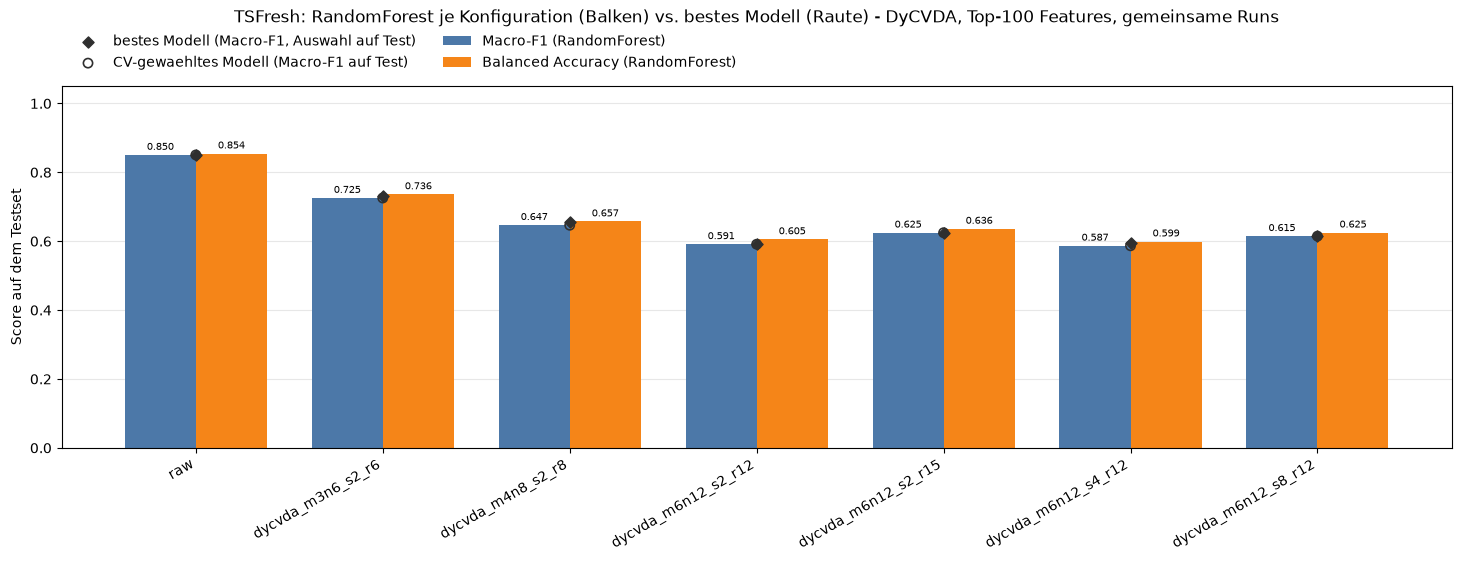

In [11]:
# ============================================================
# Plot: Hauptvergleich (RandomForest) + bestes Modell als Marker
# ============================================================
# Balken = RandomForest (festes Modell -> Konfigurationen fair
# vergleichbar). Rauten = bestes Modell je Konfiguration, ausgewaehlt auf
# dem TESTSET (leicht optimistisch, Winner's Curse). Offene Kreise = das
# auf der Train-CV gewaehlte Modell, ebenfalls mit seinem TESTwert - die
# Luecke zwischen Raute und Kreis ist der Preis des Winner's Curse.
import matplotlib.pyplot as plt

rf_d = (rf.set_index("Konfiguration").reindex(order)
        if not rf.empty else pd.DataFrame(index=order))
best_d = best_per_config.set_index("Konfiguration").reindex(order)

x = np.arange(len(order))
w = 0.38

fig, ax = plt.subplots(figsize=(14.5, 5.5), constrained_layout=True)

# Blau/Orange: unterscheidet sich auf der Blau-Gelb-Achse, die bei Prot-
# und Deuteranopie erhalten bleibt; Werte stehen zusaetzlich an den Balken.
b1 = ax.bar(x - w / 2, rf_d.get("MacroF1", pd.Series(np.nan, index=order)),
            w, label="Macro-F1 (RandomForest)", color="#4C78A8", zorder=2)
b2 = ax.bar(x + w / 2, rf_d.get("BalancedAcc", pd.Series(np.nan, index=order)),
            w, label="Balanced Accuracy (RandomForest)", color="#F58518",
            zorder=2)
for bars in (b1, b2):
    vals = [b.get_height() for b in bars]
    ax.bar_label(bars, labels=["" if np.isnan(v) else f"{v:.3f}" for v in vals],
                 fontsize=7, padding=2)

# Bestes Modell je Konfiguration als Raute (nur Macro-F1, die Kernzahl).
ax.scatter(x, best_d["MacroF1"], marker="D", s=32, color="#2f2f2f", zorder=3,
           label="bestes Modell (Macro-F1, Auswahl auf Test)")

# Das auf der Train-CV gewaehlte Modell als offener Kreis - gezeigt wird
# sein TESTwert. cv_best kommt aus der Vergleichszelle und ist None, wenn
# ohne CV gelaufen wurde (LC_CV_FOLDS = 0).
try:
    cv_best
except NameError:
    cv_best = None
if cv_best is not None:
    cv_d = cv_best.set_index("Konfiguration").reindex(order)
    ax.scatter(x, cv_d["MacroF1"], marker="o", s=44, facecolors="none",
               edgecolors="#2f2f2f", linewidths=1.2, zorder=4,
               label="CV-gewaehltes Modell (Macro-F1 auf Test)")

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("Score auf dem Testset")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Legende ueber der Achse (3 Eintraege -> 2 Zeilen); pad haelt den Titel
# frei. Im Plot selbst wuerde sie Balken oder Marker verdecken.
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=2, frameon=False)
ax.set_title(f"TSFresh: RandomForest je Konfiguration (Balken) vs. bestes "
             f"Modell (Raute) - DyCVDA, Top-{TOP_K} Features, "
             f"{'gemeinsame' if RESTRICT_TO_COMMON_RUNS else 'alle'} Runs",
             pad=46)

plt.show()

## Confusion-Matrizen je Konfiguration

Dieselbe Auswertung wie am Ende von `LazyClassifier_PCA_DyCA.ipynb`, hier über
alle 7 Konfigurationen: **ein fester Modelltyp** — RandomForest, also der
Hauptvergleich von oben — wird pro Konfiguration auf dem **gesamten**
Trainingssatz gefittet und **einmal** auf dem echten Testset ausgewertet. Die
Unterschiede zwischen den Matrizen liegen damit allein an den Features.

**Warum neu gefittet wird.** Phase C berechnet die Vorhersagen zwar schon
(`predictions=True`), überschreibt `preds` aber je Konfiguration und hebt nichts
davon auf. Ein einzelner RF-Fit je Konfiguration auf `TOP_K = 100` Features
kostet Sekunden bis rund eine Minute — deutlich billiger, als Phase C mit ~25
Modellen zu wiederholen. Die Zelle gleicht am Ende gegen
`tsfresh_summary_dycvda.csv` ab, ob sie die dortige RandomForest-Zeile
reproduziert.

**Datenbasis identisch zu Phase C:** gemeinsame Runs
(`RESTRICT_TO_COMMON_RUNS`), dieselbe NaN/inf-Behandlung, `StandardScaler` +
RandomForest wie lazypredict intern. Die gemeinsamen Runs werden hier neu
bestimmt — die Zelle läuft also auch ohne vorher gelaufenes Phase C, solange
`train_top`/`test_top` aus Phase A/B im Kernel liegen.

**Darstellung.** Die Matrizen sind **zeilenweise normiert** (Zeilensumme = 1):
Zelle (i, j) ist der Anteil der wahren Klasse *i*, der als *j* vorhergesagt
wurde, die Diagonale also der Recall. Alle Panels teilen sich die Skala 0…1 und
sind dadurch direkt vergleichbar. Die absoluten Zählwerte stehen als
21×21-DataFrame in `cm_counts[name]`.

> **Zum `raw`-Panel:** die Features sind bitidentisch zu denen in den
> Schwester-Notebooks, die *Runmenge* ist es nicht unbedingt:
> `RESTRICT_TO_COMMON_RUNS` schneidet hier auf die Runs zu, die auch die
> DyCA-Stufe überlebt haben — je nachdem, welche Runs dort scheitern, sind die
> `raw`-Matrizen der drei Notebooks ähnlich, aber nicht notwendig identisch.

Die Vorhersagen werden als `tsfresh_cm_predictions_dycvda.csv` im Cache
abgelegt (eigener Name, damit die Dateien der Schwester-Notebooks im geteilten
`CACHE_DIR` nicht überschrieben werden): nach einem Kernel-Neustart laufen die
Plotzellen darunter ohne Phase A/B/C. `CM_REFIT = True` erzwingt die
Neuberechnung.

In [12]:
# ============================================================
# Confusion-Matrizen: RandomForest je Konfiguration
# ============================================================
# Wie am Ende von LazyClassifier_PCA_DyCA.ipynb, hier ueber alle
# Konfigurationen dieses Notebooks. Fester Modelltyp (RandomForest, wie im
# Hauptvergleich) -> die Unterschiede zwischen den Matrizen liegen allein
# an den Features.
#
# Datenbasis exakt wie Phase C: gemeinsame Runs, gleiche NaN-Behandlung,
# StandardScaler + RandomForest (wie lazypredict intern). Die gemeinsamen
# Runs werden hier neu bestimmt, damit die Zelle auch OHNE gelaufenes
# Phase C funktioniert - es reichen train_top/test_top aus Phase A/B.
#
# CM_REFIT=False nutzt den Vorhersage-Cache; nach einem Kernel-Neustart
# laufen die Plotzellen darunter damit ganz ohne Phase A/B/C.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

CM_REFIT    = False                  # True = Cache ignorieren und neu fitten
# Eigener Cache-Name: CACHE_DIR ist mit den Schwester-Notebooks geteilt,
# deren Vorhersagen sollen nicht ueberschrieben werden.
CM_PRED_CSV = "tsfresh_cm_predictions_dycvda.csv"
LABELS      = list(range(21))        # Fault-Klassen 0..20, feste Achsenreihenfolge

cm_order     = [config_name(c) for c in CONFIGS]
cm_pred_path = os.path.join(CACHE_DIR, CM_PRED_CSV)

if os.path.exists(cm_pred_path) and not CM_REFIT:
    cm_pred = pd.read_csv(cm_pred_path)
    print(f"Vorhersagen aus {cm_pred_path} geladen "
          f"({cm_pred['Konfiguration'].nunique()} Konfigurationen, "
          f"{len(cm_pred)} Zeilen). CM_REFIT=True erzwingt Neuberechnung.")
else:
    try:
        train_top, test_top
    except NameError:
        raise RuntimeError(
            "train_top/test_top fehlen und es gibt keinen Vorhersage-Cache -> "
            "zuerst Phase A und B ausfuehren (laufen aus dem Chunk-Cache).")

    # Gemeinsame Runs - identische Logik wie in Phase C.
    if RESTRICT_TO_COMMON_RUNS:
        idx_tr = sorted(set.intersection(*(set(d.index) for d in train_top.values())))
        idx_te = sorted(set.intersection(*(set(d.index) for d in test_top.values())))
        print(f"Gemeinsame Runs: Train {len(idx_tr)}, Test {len(idx_te)}")
    else:
        idx_tr = idx_te = None

    parts = []
    for name in cm_order:
        t0 = time.perf_counter()
        Xtr, Xte = train_top[name], test_top[name]
        if RESTRICT_TO_COMMON_RUNS:
            Xtr, Xte = Xtr.loc[idx_tr], Xte.loc[idx_te]

        ytr = labels_from_index(Xtr.index).to_numpy()
        yte = labels_from_index(Xte.index).to_numpy()
        # NaN/inf koennen aus Featureberechnungen stammen -> auffuellen.
        Xtr_v = np.nan_to_num(Xtr.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)
        Xte_v = np.nan_to_num(Xte.to_numpy(dtype=np.float64), posinf=0.0, neginf=0.0)

        # Fit auf dem GANZEN Trainingssatz, danach genau EINE Auswertung
        # auf dem echten Testset.
        model = make_pipeline(StandardScaler(),
                              RandomForestClassifier(random_state=42, n_jobs=-1))
        model.fit(Xtr_v, ytr)
        y_pred = model.predict(Xte_v)

        parts.append(pd.DataFrame({"Konfiguration": name,
                                   "run_id": np.asarray(Xte.index),
                                   "y_true": yte,
                                   "y_pred": y_pred}))
        print(f"[{name:20s}] MacroF1 "
              f"{f1_score(yte, y_pred, average='macro', zero_division=0):.4f} | "
              f"BA {balanced_accuracy_score(yte, y_pred):.4f} "
              f"({time.perf_counter() - t0:.0f} s)")

    cm_pred = pd.concat(parts, ignore_index=True)
    cm_pred.to_csv(cm_pred_path, index=False)
    print(f"\nVorhersagen gespeichert: {cm_pred_path}")

# --- Matrizen aufbauen -------------------------------------------------
# labels=LABELS erzwingt die Reihenfolge 0..20 auch fuer Klassen, die nie
# vorhergesagt werden -> alle Matrizen sind deckungsgleich.
cm_results, cm_counts = {}, {}
for name in cm_order:
    g = cm_pred[cm_pred["Konfiguration"] == name]
    if g.empty:
        continue
    cm = confusion_matrix(g["y_true"], g["y_pred"], labels=LABELS)
    # Zeilenweise normiert: Zelle (i,j) = Anteil der wahren Klasse i, der
    # als j vorhergesagt wurde; Diagonale = Recall.
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros(cm.shape, dtype=float),
                        where=row_sums > 0)
    cm_results[name] = {
        "cm": cm, "cm_norm": cm_norm, "n_test": len(g),
        "bal_acc":  balanced_accuracy_score(g["y_true"], g["y_pred"]),
        "macro_f1": f1_score(g["y_true"], g["y_pred"], average="macro",
                             zero_division=0),
    }
    cm_counts[name] = pd.DataFrame(cm, index=[f"true_{i}" for i in LABELS],
                                   columns=[f"pred_{i}" for i in LABELS])

# Abgleich mit Phase C: dieser RF muss die RandomForest-Zeile aus summary
# reproduzieren. Kleine Abweichungen sind normal (RF-Zufallskomponente,
# lazypredict haengt zusaetzlich einen SimpleImputer vor den Scaler).
_sum_path = os.path.join(CACHE_DIR, SUMMARY_CSV)
if os.path.exists(_sum_path):
    _rf = pd.read_csv(_sum_path)
    _rf = _rf[_rf["Modell"] == "RandomForestClassifier"].set_index("Konfiguration")
    _d = {n: abs(cm_results[n]["macro_f1"] - _rf.loc[n, "MacroF1"])
          for n in cm_results if n in _rf.index}
    if _d:
        _w = max(_d, key=_d.get)
        print(f"Abgleich mit Phase C: groesste Macro-F1-Abweichung "
              f"{_d[_w]:.4f} ({_w})")

print(f"\n{len(cm_results)} Matrizen berechnet. Absolute Zaehlwerte stehen "
      f"in cm_counts, z.B. cm_counts['{cm_order[0]}'].")

Gemeinsame Runs: Train 10013, Test 9996
[raw                 ] MacroF1 0.8504 | BA 0.8544 (3 s)
[dycvda_m3n6_s2_r6   ] MacroF1 0.7254 | BA 0.7359 (3 s)
[dycvda_m4n8_s2_r8   ] MacroF1 0.6467 | BA 0.6572 (3 s)
[dycvda_m6n12_s2_r12 ] MacroF1 0.5912 | BA 0.6053 (3 s)
[dycvda_m6n12_s2_r15 ] MacroF1 0.6247 | BA 0.6358 (3 s)
[dycvda_m6n12_s4_r12 ] MacroF1 0.5867 | BA 0.5990 (3 s)
[dycvda_m6n12_s8_r12 ] MacroF1 0.6147 | BA 0.6248 (3 s)

Vorhersagen gespeichert: tsfresh_cache\tsfresh_cm_predictions_dycvda.csv
Abgleich mit Phase C: groesste Macro-F1-Abweichung 0.0000 (raw)

7 Matrizen berechnet. Absolute Zaehlwerte stehen in cm_counts, z.B. cm_counts['raw'].


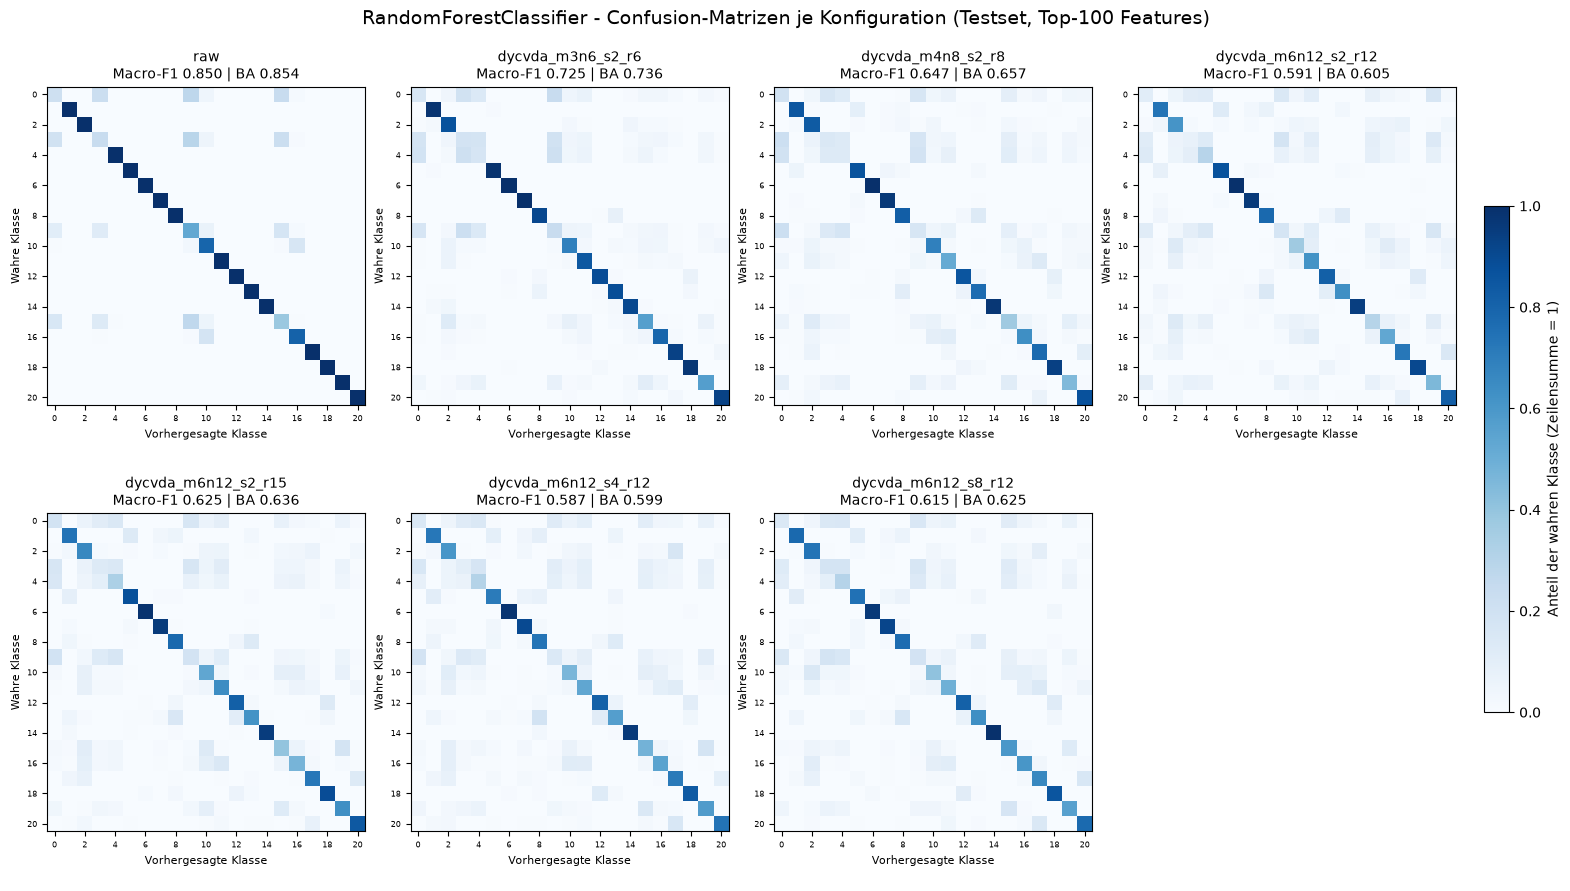

In [13]:
# ============================================================
# Plot: alle Confusion-Matrizen im Raster
# ============================================================
# Zeilenweise normiert (Zeilensumme = 1): Zelle (i, j) = Anteil der wahren
# Klasse i, der als j vorhergesagt wurde -> die Diagonale ist der Recall.
# Gemeinsame Farbskala 0..1, damit die Panels direkt vergleichbar sind.
#
# Anders als im Eigenwert-Notebook (3 Panels) werden die Zellen hier NICHT
# beschriftet - bei 7 Panels a 21x21 waere die Schrift unlesbar.
# Exakte Zahlen: cm_counts[name] bzw. das Detail-Panel darunter.
import matplotlib.pyplot as plt

CM_NCOLS = 4                      # Panels pro Zeile

names_plot = [n for n in cm_order if n in cm_results]
nrows = int(np.ceil(len(names_plot) / CM_NCOLS))

fig, axes = plt.subplots(nrows, CM_NCOLS,
                         figsize=(3.9 * CM_NCOLS, 4.4 * nrows),
                         constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, names_plot):
    res = cm_results[name]
    im = ax.imshow(res["cm_norm"], cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(f"{name}\nMacro-F1 {res['macro_f1']:.3f} | "
                 f"BA {res['bal_acc']:.3f}", fontsize=10)
    # Nur jede zweite Klasse beschriften - 21 Ticks je Achse waeren im
    # kleinen Panel eine graue Linie.
    ax.set_xticks(LABELS[::2])
    ax.set_xticklabels(LABELS[::2], fontsize=6)
    ax.set_yticks(LABELS[::2])
    ax.set_yticklabels(LABELS[::2], fontsize=6)
    ax.set_xlabel("Vorhergesagte Klasse", fontsize=8)
    ax.set_ylabel("Wahre Klasse", fontsize=8)

for ax in axes[len(names_plot):]:       # ungenutzte Panels ausblenden
    ax.axis("off")

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.6, pad=0.02)
cbar.set_label("Anteil der wahren Klasse (Zeilensumme = 1)")
fig.suptitle("RandomForestClassifier - Confusion-Matrizen je Konfiguration "
             f"(Testset, Top-{TOP_K} Features)", fontsize=14)
plt.show()

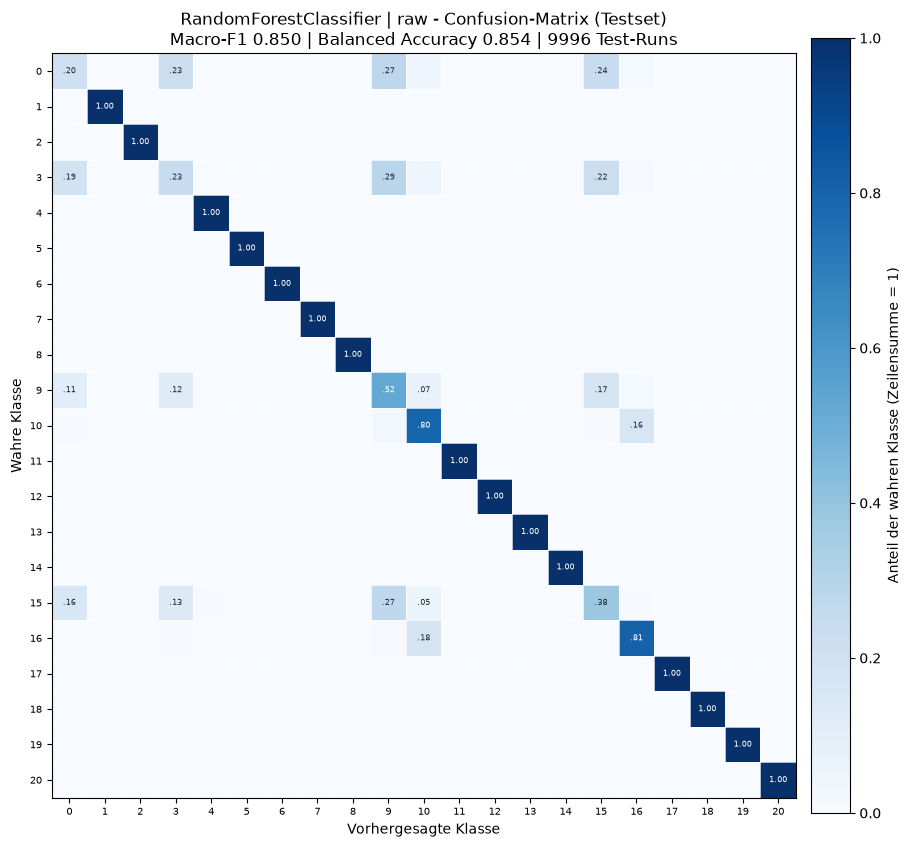

=== raw: Bericht je Klasse ===
              precision    recall  f1-score   support

           0      0.307     0.205     0.246       479
           1      1.000     1.000     1.000       481
           2      1.000     1.000     1.000       490
           3      0.326     0.235     0.273       477
           4      0.992     1.000     0.996       480
           5      1.000     1.000     1.000       475
           6      1.000     1.000     1.000       408
           7      1.000     1.000     1.000       478
           8      1.000     1.000     1.000       489
           9      0.380     0.524     0.440       485
          10      0.667     0.797     0.726       472
          11      1.000     1.000     1.000       477
          12      1.000     0.998     0.999       476
          13      1.000     1.000     1.000       476
          14      1.000     1.000     1.000       485
          15      0.370     0.380     0.375       476
          16      0.805     0.805     0.805       

,pred_0,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred_7,pred_8,pred_9,...,pred_11,pred_12,pred_13,pred_14,pred_15,pred_16,pred_17,pred_18,pred_19,pred_20
true_0,98,0,0,108,1,0,0,0,0,131,...,0,0,0,0,114,6,0,0,0,0
true_1,0,481,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_2,0,0,490,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_3,93,0,0,112,1,0,0,0,0,138,...,0,0,0,0,106,4,0,0,0,0
true_4,0,0,0,0,480,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_5,0,0,0,0,0,475,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_6,0,0,0,0,0,0,408,0,0,0,...,0,0,0,0,0,0,0,0,0,0
true_7,0,0,0,0,0,0,0,478,0,0,...,0,0,0,0,0,0,0,0,0,0
true_8,0,0,0,0,0,0,0,0,489,0,...,0,0,0,0,0,0,0,0,0,0
true_9,52,0,0,57,0,0,0,0,0,254,...,0,0,0,0,82,6,0,0,0,0


In [14]:
# ============================================================
# Detail: eine Konfiguration gross + groesste Verwechslungen
# ============================================================
# CM_FOCUS waehlt die Konfiguration (None = beste nach Macro-F1). Hier
# werden - wie im Eigenwert-Notebook - auffaellige Zellen beschriftet;
# alles unter ANNOT_MIN bliebe im 21x21-Raster ohnehin unlesbar.
CM_FOCUS  = None          # z.B. "raw" oder "dycvda_m6n12_s2_r12"; None = beste
ANNOT_MIN = 0.05          # ab diesem Anteil wird eine Zelle beschriftet
TOP_N     = 8             # so viele Verwechslungen auflisten

focus = CM_FOCUS or max(cm_results, key=lambda n: cm_results[n]["macro_f1"])
fres  = cm_results[focus]
fg    = cm_pred[cm_pred["Konfiguration"] == focus]

# figsize: imshow erzwingt ein quadratisches Panel - die Hoehe ist also
# Breite minus Colorbar/Beschriftung, plus der zweizeilige Titel. Wird die
# Figur flacher, schneidet sie die erste Titelzeile ab.
fig, ax = plt.subplots(figsize=(9, 9.2), constrained_layout=True)
im = ax.imshow(fres["cm_norm"], cmap="Blues", vmin=0.0, vmax=1.0)

ax.set_title(f"RandomForestClassifier | {focus} - Confusion-Matrix (Testset)\n"
             f"Macro-F1 {fres['macro_f1']:.3f} | "
             f"Balanced Accuracy {fres['bal_acc']:.3f} | "
             f"{fres['n_test']} Test-Runs", fontsize=12)
ax.set_xlabel("Vorhergesagte Klasse")
ax.set_ylabel("Wahre Klasse")
ax.set_xticks(LABELS)
ax.set_xticklabels(LABELS, fontsize=7)
ax.set_yticks(LABELS)
ax.set_yticklabels(LABELS, fontsize=7)

# Duenne weisse Trennlinien auf den Zellgrenzen (Minor-Ticks) - macht
# einzelne Zellen im 21x21-Raster abzaehlbar.
ax.set_xticks(np.arange(-0.5, len(LABELS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(LABELS), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.5)
ax.tick_params(which="minor", length=0)

# Selektive Beschriftung: Diagonale + relevante Verwechslungen.
# Schriftfarbe wechselt auf dunklen Zellen zu weiss (Kontrast).
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        v = fres["cm_norm"][i, j]
        if v < ANNOT_MIN:
            continue
        ax.text(j, i, f"{v:.2f}".lstrip("0"), ha="center", va="center",
                fontsize=6, color="white" if v > 0.5 else "#1f2937")

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("Anteil der wahren Klasse (Zeilensumme = 1)")
plt.show()

# zero_division=0: Klassen ohne einzige Vorhersage bekommen Precision 0
# statt einer UndefinedMetricWarning.
print(f"=== {focus}: Bericht je Klasse ===")
print(classification_report(fg["y_true"], fg["y_pred"], labels=LABELS,
                            digits=3, zero_division=0))

# Die groessten Off-Diagonal-Eintraege = die systematischen Verwechslungen.
# Genau das, was man in der Grafik sucht, hier als sortierte Liste.
err = fres["cm"].astype(float).copy()
np.fill_diagonal(err, 0.0)                 # Diagonale = Treffer, nicht relevant
print(f"=== {focus}: groesste Verwechslungen (Top {TOP_N}) ===")
for flat_idx in np.argsort(err, axis=None)[::-1][:TOP_N]:
    i, j = np.unravel_index(flat_idx, err.shape)
    n_runs = int(err[i, j])
    if n_runs == 0:
        break                              # ab hier nur noch Nullen
    share = n_runs / fres["cm"][i].sum()
    print(f"  wahr {LABELS[i]:>2d} -> vorhergesagt {LABELS[j]:>2d}: "
          f"{n_runs:4d} Runs ({share:.1%} der Klasse)")

cm_counts[focus]

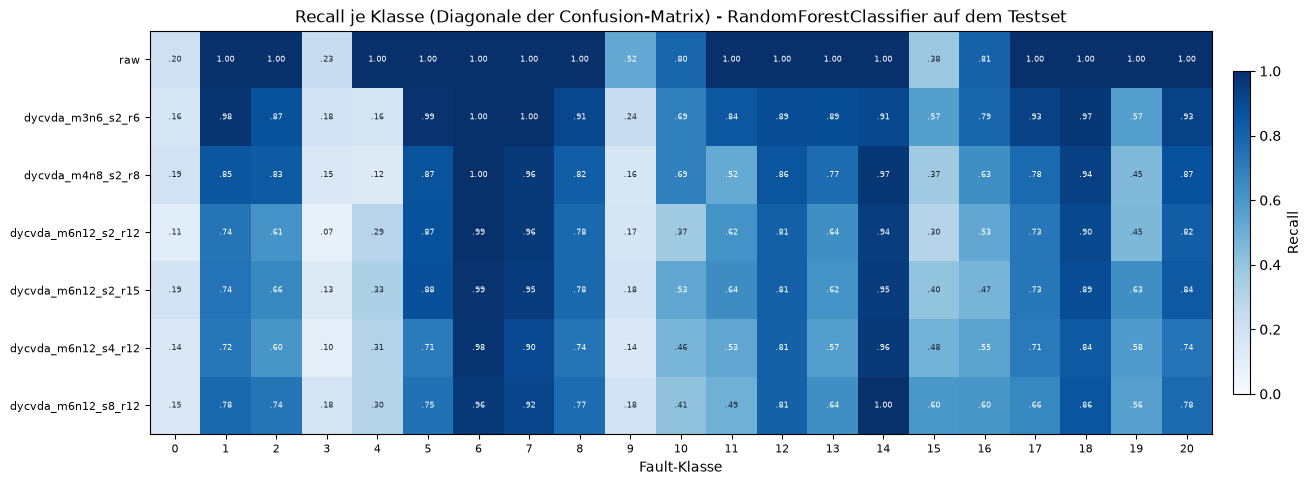

Schwierigste Klassen (mittlerer Recall ueber alle Konfigurationen):
faultNumber
3     0.149
0     0.163
9     0.227
4     0.360
15    0.441


faultNumber,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
Konfiguration,,,,,,,,,,,,,,,,,,,,,
raw,0.205,1.000,1.000,0.235,1.000,1.000,1.000,1.000,1.000,0.524,...,1.000,0.998,1.000,1.000,0.380,0.805,1.000,1.000,1.000,1.000
dycvda_m3n6_s2_r6,0.157,0.983,0.867,0.182,0.165,0.985,0.998,0.998,0.910,0.235,...,0.845,0.889,0.887,0.905,0.565,0.792,0.933,0.971,0.569,0.928
dycvda_m4n8_s2_r8,0.192,0.852,0.835,0.147,0.125,0.865,1.000,0.964,0.824,0.161,...,0.518,0.859,0.767,0.971,0.368,0.633,0.776,0.937,0.445,0.874
dycvda_m6n12_s2_r12,0.109,0.738,0.612,0.071,0.294,0.869,0.993,0.960,0.781,0.169,...,0.621,0.813,0.637,0.944,0.298,0.528,0.725,0.904,0.454,0.822
dycvda_m6n12_s2_r15,0.186,0.740,0.661,0.130,0.329,0.878,0.988,0.954,0.781,0.181,...,0.644,0.813,0.620,0.953,0.399,0.470,0.725,0.889,0.634,0.843
dycvda_m6n12_s4_r12,0.144,0.723,0.604,0.099,0.306,0.709,0.983,0.902,0.736,0.138,...,0.535,0.809,0.569,0.959,0.479,0.547,0.713,0.839,0.580,0.741
dycvda_m6n12_s8_r12,0.146,0.778,0.737,0.176,0.304,0.749,0.963,0.916,0.769,0.181,...,0.491,0.809,0.637,0.996,0.601,0.604,0.662,0.856,0.561,0.776


In [15]:
# ============================================================
# Recall je Fault-Klasse und Konfiguration
# ============================================================
# Die Diagonalen aller Matrizen in einer Tabelle: zeigt, WELCHE Faults eine
# Projektion traegt und welche sie verliert. Der Skalarvergleich (Macro-F1
# im Hauptvergleich) sagt das nicht - zwei Konfigurationen mit gleichem
# Mittel koennen an voellig verschiedenen Klassen scheitern.
recall_tab = pd.DataFrame(
    {name: np.diag(res["cm_norm"]) for name, res in cm_results.items()},
    index=LABELS).T
recall_tab.index.name   = "Konfiguration"
recall_tab.columns.name = "faultNumber"

fig, ax = plt.subplots(figsize=(13, 0.42 * len(recall_tab) + 1.8),
                       constrained_layout=True)
# aspect="auto": die Tabelle ist breit und flach, quadratische Zellen
# wuerden die Figur unnoetig hoch machen.
im = ax.imshow(recall_tab.to_numpy(), cmap="Blues", vmin=0.0, vmax=1.0,
               aspect="auto")

ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, fontsize=8)
ax.set_yticks(range(len(recall_tab)))
ax.set_yticklabels(recall_tab.index, fontsize=8)
ax.set_xlabel("Fault-Klasse")
ax.set_title("Recall je Klasse (Diagonale der Confusion-Matrix) - "
             "RandomForestClassifier auf dem Testset")

for i in range(recall_tab.shape[0]):
    for j in range(recall_tab.shape[1]):
        v = recall_tab.iat[i, j]
        ax.text(j, i, f"{v:.2f}".lstrip("0"), ha="center", va="center",
                fontsize=6, color="white" if v > 0.5 else "#1f2937")

fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02).set_label("Recall")
plt.show()

print("Schwierigste Klassen (mittlerer Recall ueber alle Konfigurationen):")
print(recall_tab.mean(axis=0).sort_values().head(5).round(3).to_string())

recall_tab.round(3)

## Wo weitergemacht werden kann

- **Feature-Namen ansehen:** `top_names["dycvda_m6n12_s2_r12"]` zeigt,
  *welche* TSFresh-Features eine Konfiguration ausgewählt hat — und vor
  allem, aus welchen `cvd`-Kanälen sie stammen. Landet fast alles auf
  `cvd1`–`cvd3` (den stärksten kanonischen Korrelationen), trägt der
  Dissimilaritätsanteil der schwachen Kanäle wenig.
- **r-Verschachtelung prüfen:** `set(top_names["dycvda_m6n12_s2_r15"]) ==
  set(top_names["dycvda_m6n12_s2_r12"])` beantwortet direkt, ob die drei
  zusätzlichen Kanäle des Paper-Settings für die Top-100 überhaupt eine
  Rolle spielen (vgl. das `pca_6`/`pca_8`-Phänomen).
- **Quervergleich mit den Schwester-Notebooks:** `tsfresh_summary.csv`
  (PCA/DyCA), `tsfresh_summary_dpca_cva_ica.csv` (DPCA/CVA/ICA) und
  `tsfresh_summary_dycvda.csv` (dieses Notebook) liegen im selben
  Cache-Ordner und teilen die `raw`-Zeilen als gemeinsamen Anker — alle drei
  CSVs laden, konkatenieren und über sämtliche Konfigurationen plotten.
  Besonders interessant: `dycvda_m6n12_s2_r12` gegen `dyca_m6_n12` (gleiche
  DyCA-Stufe, mit vs. ohne CVA-Dissimilarität) und gegen `cva_12`
  (CVA-Idee auf Rohdaten vs. auf DyCA-Amplituden).
- **`TOP_K` variieren:** die Auswahl ist gecacht, ein anderer Wert erzwingt
  eine neue Selektion; die teure Train-Extraktion in `CACHE_DIR` bleibt
  gültig. **Achtung** (Familienthema, gilt auch in den Schwester-Notebooks):
  die Phase-B-Test-Chunks (`*__test__top__*.pkl`) kodieren `TOP_K` nicht —
  vor einer Änderung diese Chunks für die betroffenen Konfigurationen
  löschen, sonst werden neue Features stumm mit 0.0 aufgefüllt.
- **CV wieder abschalten:** `LC_CV_FOLDS = 0` in der Konfigurationszelle nimmt
  die 5-fache Train-CV aus Phase C heraus und spart grob das 2- bis 4-Fache der
  Phase-C-Zeit; die Modellauswahl fällt dann auf das Test-Maximum zurück. Die
  teuren Phasen A/B sind nicht betroffen und bleiben gecacht.
- **Parameter variieren:** neue (m, n, s, r)-Tupel in `DYCVDA_CONFIGS` sind
  gefahrlos — alle vier Parameter stecken im Konfigurationsnamen und damit im
  Cache-Präfix, ein Wechsel erzeugt neue Chunks statt alte stumm zu laden.
  Ausnahmen: `CVA_RIDGE_REL` und `FIX_SIGNS` stehen nicht im Namen — bei
  Änderung vorher die `dycvda_*`-Chunks löschen.
- **Papiertreue Offline-Variante:** DyCA + CVA einmal auf den
  Fault-0-Trainingsruns fitten (Θ‡, J, L, Λ fest) und alle Runs mit dieser
  festen Projektion abbilden — das entspricht dem Offline/Online-Schema des
  Papers und macht die d-Kanäle über Runs hinweg physikalisch vergleichbar
  (lageabhängige TSFresh-Features werden dann uneingeschränkt sinnvoll).
  Optional zusätzlich den skalaren Monitoring-Index D(t) (Paper Gl. 16) als
  1-Kanal-Konfiguration mitlaufen lassen — der direkte Test, ob die
  Detektionsstatistik auch Klassifikationsinformation trägt.
- **Skalierung umstellen:** `SCALING_MODE` in der Konfigurationszelle
  (`"global_mean"` ↔ `"scaler"`); der Cache-Ordner bekommt den Modus
  automatisch angehängt, alte Ergebnisse werden nicht überschrieben.
- **Confusion-Matrizen:** die Zellen oben halten `cm_results` (Matrizen +
  Scores), `cm_counts` (absolute Zählwerte je Konfiguration) und `recall_tab`
  (Recall je Klasse) bereit. Für ein anderes Modell dort den
  `RandomForestClassifier(...)` austauschen und `CM_REFIT = True` setzen —
  sonst wird der Vorhersage-Cache `tsfresh_cm_predictions_dycvda.csv`
  weiterverwendet.